# Overview

This code builds upon a previous script, *Rain_shift_run*, which generates output stored as a pickle file.  
The pickle file contains simulation results of storm events over a spatial domain, organized by shifts in the X and Y axes.  

The main purpose of the code is to compare a historical storm event with a future storm scenario.  
The future event varies based on two key parameters:  
1. Changes in the percentage of impervious surfaces.  
2. Whether the storm is historical or a future projection.  

For each run, the code loads a specific pickle file (e.g., a future storm scenario with 1.5x impervious surface area) and analyzes the flow data for the Ra'anana Basin.


## Imports and Functions

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors


In [2]:
def compute_r2(data, intensity_cols, discharge_col):
    r2_values = {}
    for col in intensity_cols:
        # Drop NaNs to avoid errors in linear regression
        valid_data = data[[col, discharge_col]].dropna()
        if valid_data.empty:
            r2_values[col] = np.nan
            continue
        X = valid_data[col].values.reshape(-1, 1)
        y = valid_data[discharge_col].values
        model = LinearRegression().fit(X, y)
        y_pred = model.predict(X)
        r2_values[col] = r2_score(y, y_pred)
    return r2_values

In [3]:
# Define paths and rain shift classes
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"


rain_shift_classes = [
# Historical rain with urbanization
('rain_shift_results_control.pkl', '38% urbanization'),
('rain_shift_results_1_1_urbanization_historical_rain.pkl', '42% urbanization'),
('rain_shift_results_1_2_urbanization_historical_rain.pkl', '46% urbanization'),
('rain_shift_results_1_3_urbanization_historical_rain.pkl', '49% urbanization'),
('rain_shift_results_1_4_urbanization_historical_rain.pkl', '53% urbanization'),
('rain_shift_results_1_5_urbanization_historical_rain.pkl', '57% urbanization'),
('rain_shift_results_2_0_urbanization_historical_rain.pkl', '73% urbanization'),
('rain_shift_results_3_0_urbanization_historical_rain.pkl', '81% urbanization'),
('rain_shift_results_5_0_urbanization_historical_rain.pkl', '87% urbanization'),

# Climate Change with urbanization       
('rain_shift_results_1_0_urbanization.pkl', 'Climate Change 38% urbanization'),
('rain_shift_results_1_1_urbanization.pkl', 'Climate Change 42% urbanization'),
('rain_shift_results_1_2_urbanization.pkl', 'Climate Change 46% urbanization'),
('rain_shift_results_1_3_urbanization.pkl', 'Climate Change 49% urbanization'),
('rain_shift_results_1_4_urbanization.pkl', 'Climate Change 53% urbanization'),
('rain_shift_results_1_5_urbanization.pkl', 'Climate Change 57% urbanization'),
('rain_shift_results_2_0_urbanization.pkl', 'Climate Change 73% urbanization'),
('rain_shift_results_3_0_urbanization.pkl', 'Climate Change 81% urbanization'),
('rain_shift_results_5_0_urbanization.pkl', 'Climate Change 87% urbanization'),

]
    
# Define groups and intensity columns
# basin_rain_groups = ['full_basin', 'singular_subcatchment', 'before_peak']
basin_rain_groups = ['full_basin']
# Select the rain shift index
rain_shift_idx = 2
pickle_file, label_name = rain_shift_classes[rain_shift_idx]

# Build paths
pickle_file_path = os.path.join(sim_dir, pickle_file)
# save_dir = os.path.join(r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts', save_dir_file, 'metrics')
# os.makedirs(save_dir, exist_ok=True)

# Load data
final_results_df = pd.read_pickle(pickle_file_path)

# Filter data based on shift threshold
shift_threshold = 20000  # meters
final_results_df = final_results_df[
    (final_results_df[('y', '', '')] <= shift_threshold) & 
    (final_results_df[('y', '', '')] >= -shift_threshold)
]

# Update the MultiIndex to replace 'Least_Urban_s28' with 'Least_Urban_S28'
final_results_df.columns = final_results_df.columns.map(
    lambda col: tuple('Least_Urban_S28' if level == 'Least_Urban_s28' else level for level in col)
)

## Filter events with low rainfall

In [4]:
rain_filter_threshold = 10  # mm
event_nums_to_filter_out = []
for event in final_results_df[('event_num', '', '')].unique():
    event_df = final_results_df[final_results_df[('event_num', '', '')] == event]
    if (event_df[('historical', 'full_basin', 'total_rain')] < rain_filter_threshold).all() and \
       (event_df[('future', 'full_basin', 'total_rain')] < rain_filter_threshold).all():
        event_nums_to_filter_out.append(event)

final_results_df = final_results_df[~final_results_df[('event_num', '', '')].isin(event_nums_to_filter_out)]
print(f'{len(event_nums_to_filter_out)} events removed due to total event rain smaller than {rain_filter_threshold} mm')

8 events removed due to total event rain smaller than 10 mm


## Max discharge Vs rain intensities corroletion

Maximum Historical R²: Key: ('historical', 'full_basin', 'max_60min_intensity'), Value: 0.7519650799401498
Second Highest Historical R²: Key: ('historical', 'full_basin', 'max_120min_intensity'), Value: 0.7286134615202879
Maximum Future r²: Key: ('future', 'full_basin', 'max_60min_intensity'), Value: 0.770234833851241
Second Highest Future R²: Key: ('future', 'full_basin', 'max_120min_intensity'), Value: 0.7502609350925421


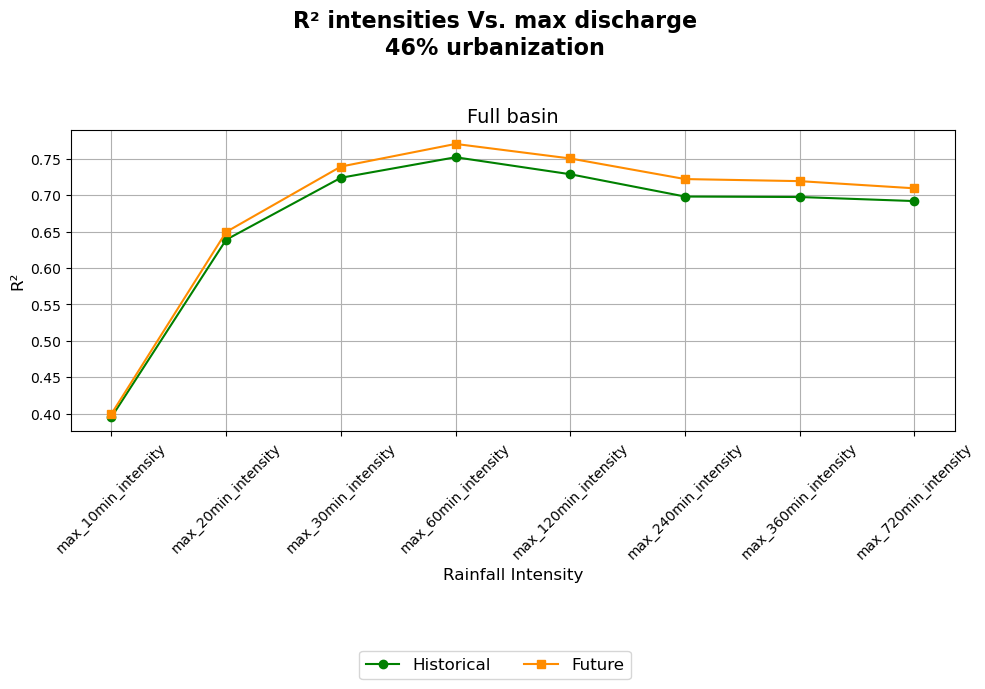

In [5]:
historical_max_discharge_col = ('historical', 'basin discharge', 'max_discharge')
future_max_discharge_col = ('future', 'basin discharge', 'max_discharge')

# Initialize the figure for subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharey=True)

# Since basin_rain_groups contains only one item, use a single axis
group = basin_rain_groups[0]

# Define intensity columns for the current group
intensity_cols = [
    ('historical', group, 'max_10min_intensity'),
    ('historical', group, 'max_20min_intensity'),
    ('historical', group, 'max_30min_intensity'),
    ('historical', group, 'max_60min_intensity'),
    ('historical', group, 'max_120min_intensity'),
    ('historical', group, 'max_240min_intensity'),
    ('historical', group, 'max_360min_intensity'),
    ('historical', group, 'max_720min_intensity'),
]
future_intensity_cols = [(col[0].replace('historical', 'future'), col[1], col[2]) for col in intensity_cols]

# Compute R² values for historical and future data
historical_r2 = compute_r2(final_results_df, intensity_cols, historical_max_discharge_col)
future_r2 = compute_r2(final_results_df, future_intensity_cols, future_max_discharge_col)

# Find and print the maximum R² values and their corresponding keys
max_historical_r2 = max(historical_r2.items(), key=lambda x: x[1])
max_future_r2 = max(future_r2.items(), key=lambda x: x[1])

# Find and print the second highest R² values
second_max_historical_r2 = sorted(historical_r2.items(), key=lambda x: x[1], reverse=True)[1]
second_max_future_r2 = sorted(future_r2.items(), key=lambda x: x[1], reverse=True)[1]

print(f"Maximum Historical R²: Key: {max_historical_r2[0]}, Value: {max_historical_r2[1]}")
print(f"Second Highest Historical R²: Key: {second_max_historical_r2[0]}, Value: {second_max_historical_r2[1]}")
print(f"Maximum Future r²: Key: {max_future_r2[0]}, Value: {max_future_r2[1]}")
print(f"Second Highest Future R²: Key: {second_max_future_r2[0]}, Value: {second_max_future_r2[1]}")

# Plot R² values
ax.plot(
    [col[2] for col in intensity_cols],
    list(historical_r2.values()),
    color='green', marker='o', label='Historical'
)
ax.plot(
    [col[2] for col in future_intensity_cols],
    list(future_r2.values()),
    color='darkorange', marker='s', label='Future'
)

# Set title and labels
ax.set_title(f'{group.capitalize().replace("_", " ")}', fontsize=14)
ax.set_xlabel('Rainfall Intensity', fontsize=12)
ax.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for clarity
ax.set_ylabel('R²', fontsize=12)
ax.grid(True)

# Add an overall title for the figure
fig.suptitle(
    f'R² intensities Vs. max discharge\n{rain_shift_classes[rain_shift_idx][1]}',
    fontsize=16, fontweight='bold'
)

# Create a single legend for the figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.15))

# Adjust layout for a clean, uniform appearance
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to leave space for the legend and title

# Save and show the plot
# os.makedirs(save_dir, exist_ok=True)
# save_dir_path = os.path.join(save_dir, 'max_discharge_intensities_r2_plot.png')
# plt.savefig(save_dir_path, bbox_inches='tight')  # Ensure the legend fits inside the saved file
plt.show()


In [6]:
max_historical_r2 = max(historical_r2.items(), key=lambda x: x[1])
max_future_r2 = max(future_r2.items(), key=lambda x: x[1])
# max_historical_r2
max_future_r2

(('future', 'full_basin', 'max_60min_intensity'), 0.770234833851241)

## Total discharge Vs rain intensities corroletion

# All events mean value bar plot

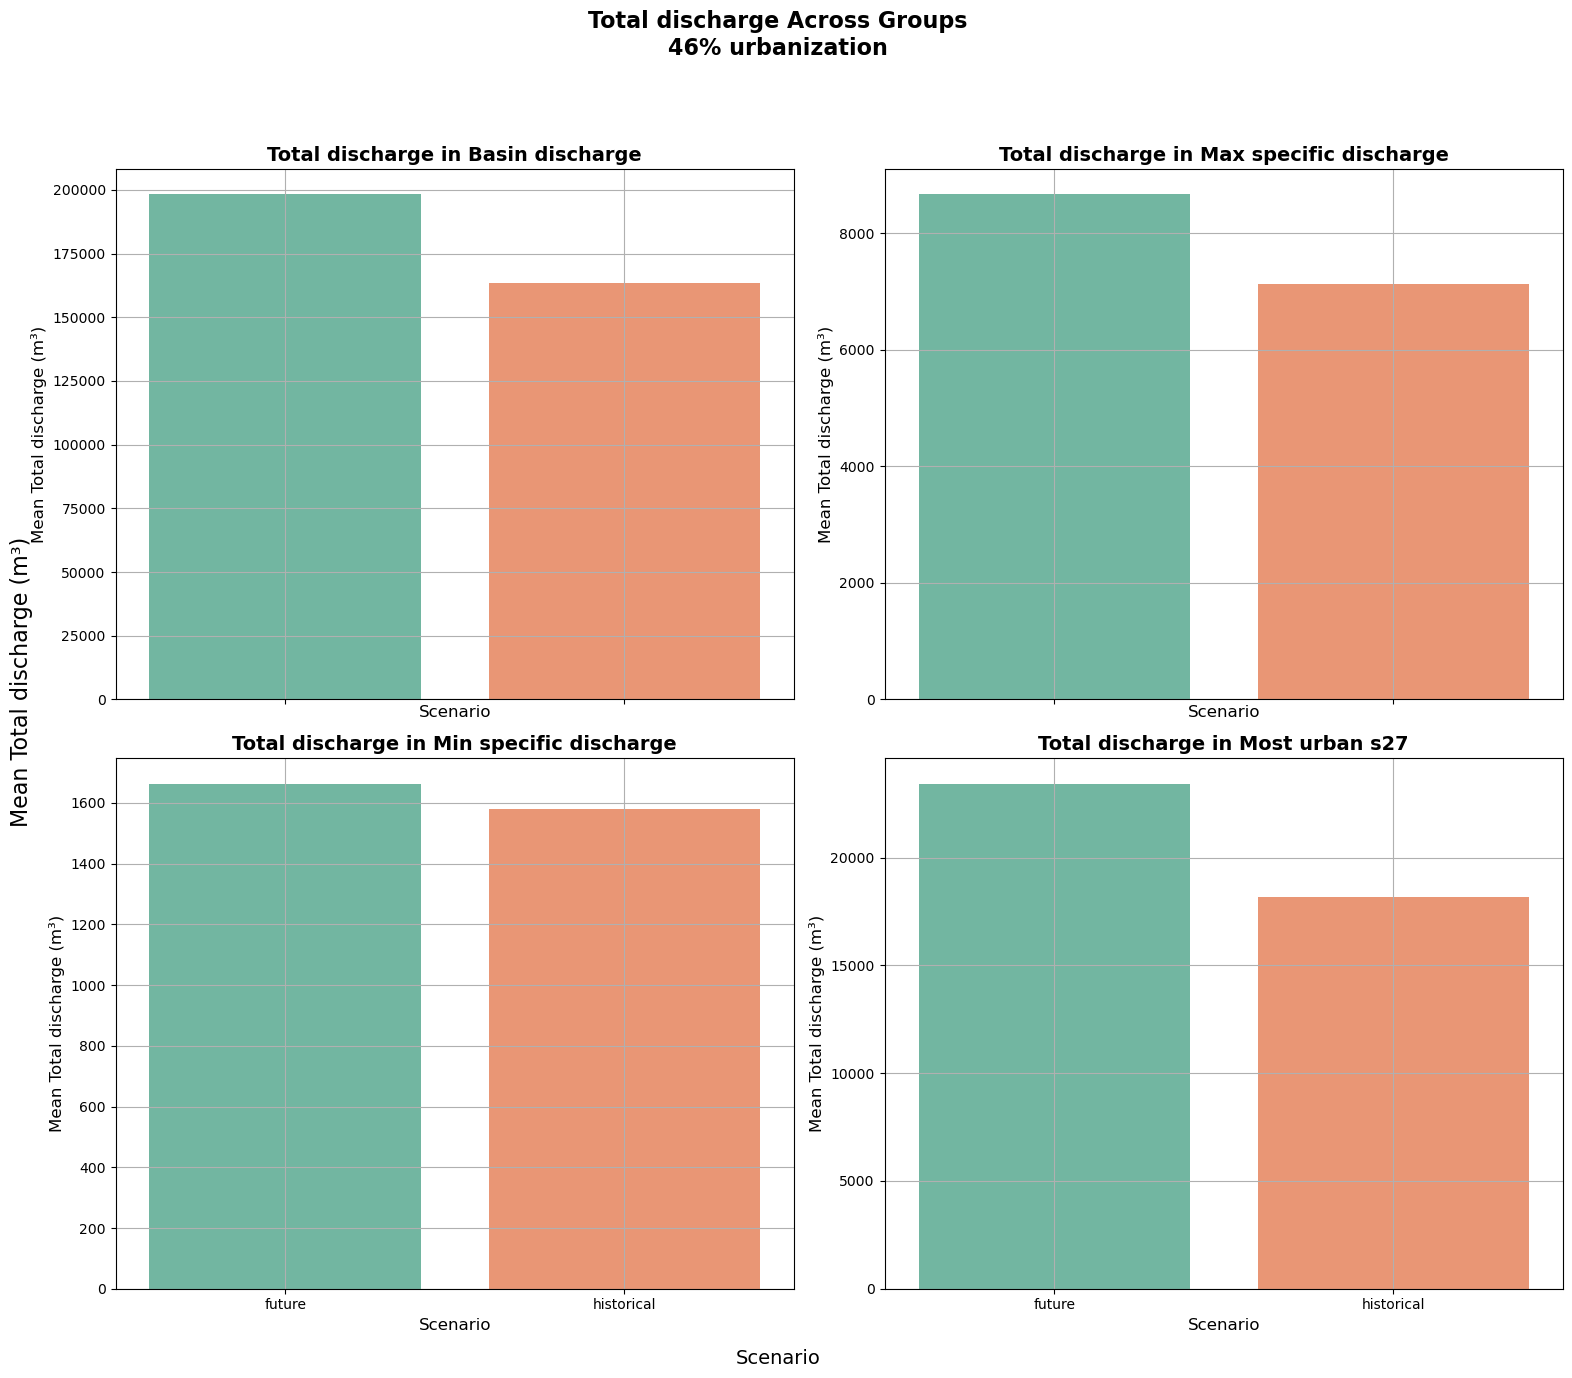

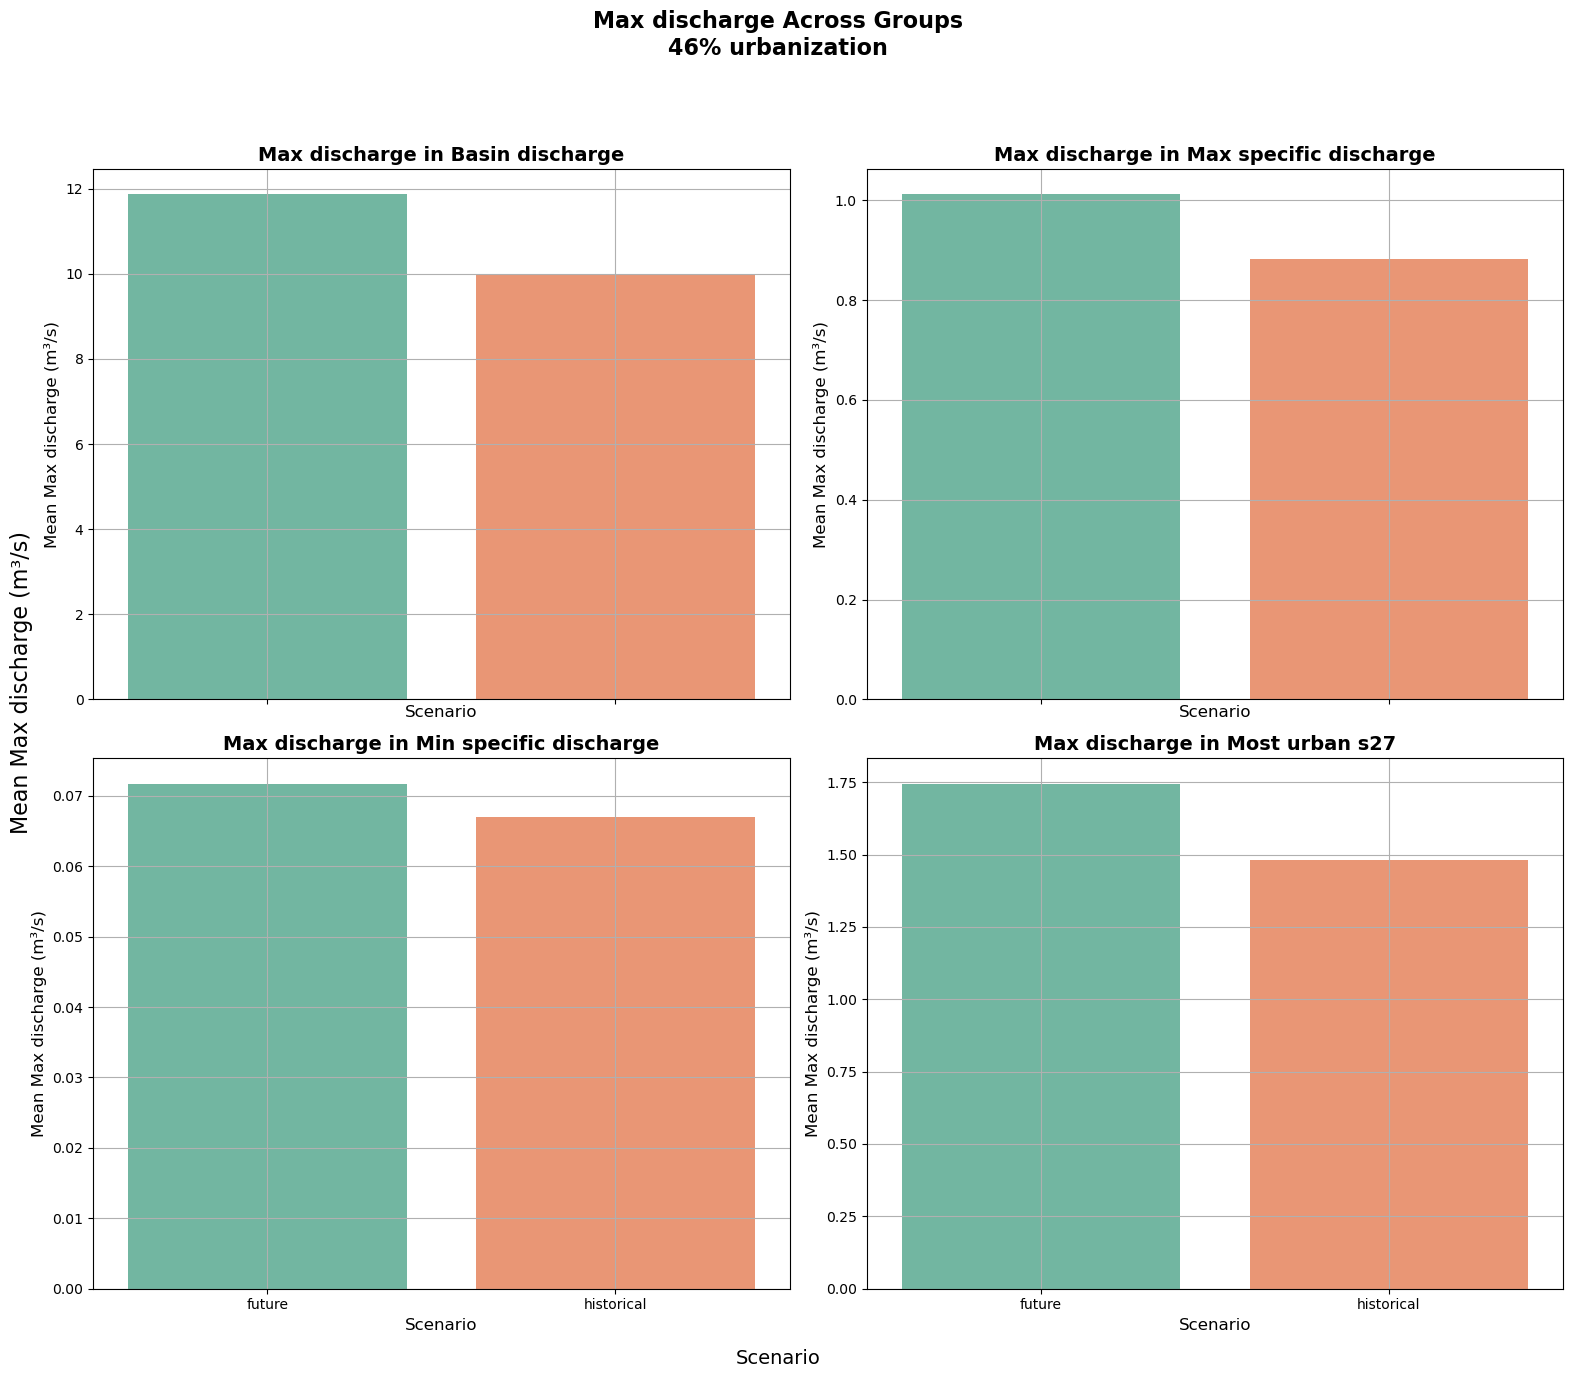

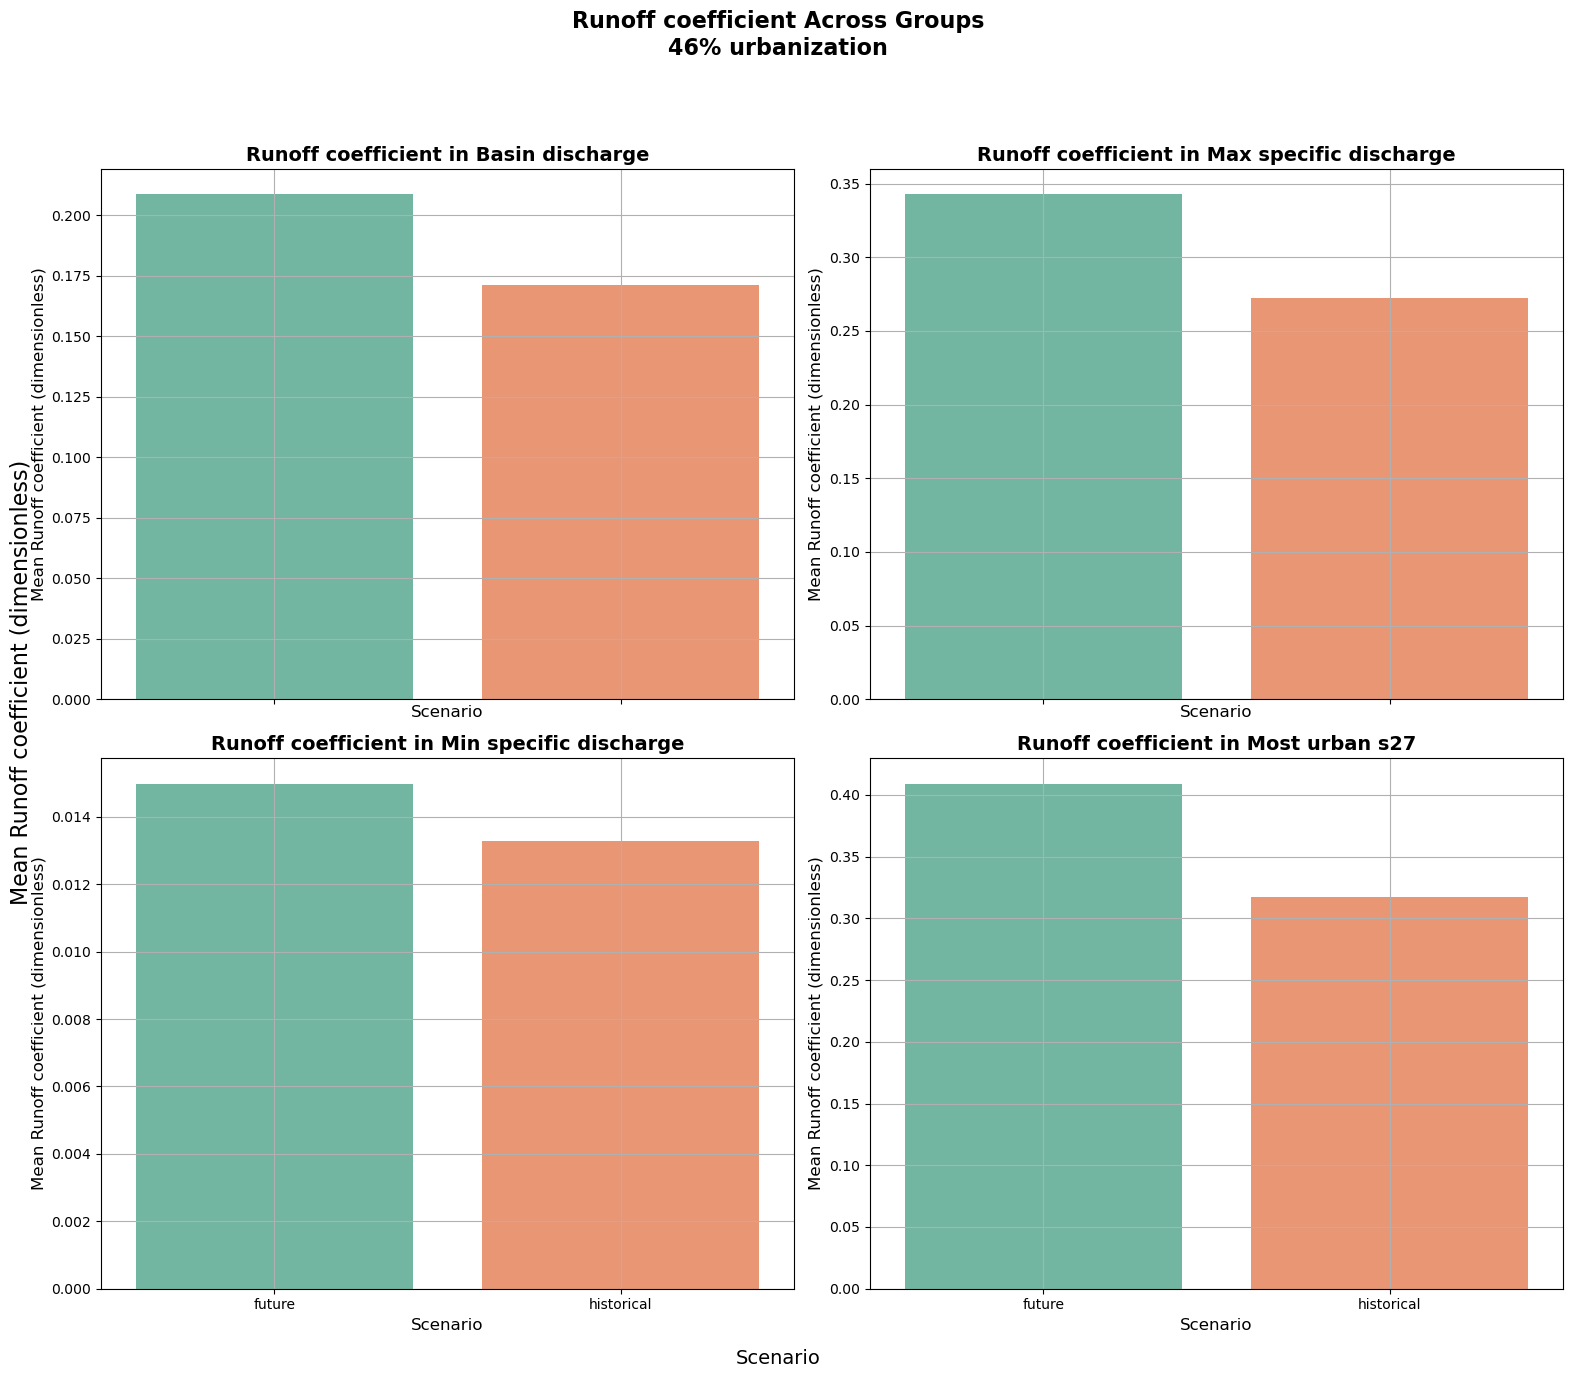

In [7]:
# Define the groups and rain parameters
groups = ['basin discharge', 'Max_Specific_Discharge', 'Min_Specific_Discharge', 'Most_Urban_S27', 'Least_Urban_s28']
rain_parameters = {
    'total_discharge': '(m³)',
    'max_discharge': '(m³/s)',
    'runoff_coefficient': '(dimensionless)'
}

# Loop through each rain parameter
for measure, unit in rain_parameters.items():
    # Create a 2x2 figure for bar plots
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14), sharex=True)

    # Flatten axes for easier handling
    axes = axes.flatten()

    for idx, group in enumerate(groups[:4]):  # Ensure we only take 4 groups for the 2x2 layout
        # Melt the DataFrame for the specific group and measure
        melted_df = final_results_df.melt(
            id_vars=[('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')],
            value_vars=[
                ('historical', group, measure),
                ('future', group, measure)
            ],
            var_name=['scenario', 'group', 'measure'],
            value_name='value'
        )

        # Flatten column names for seaborn compatibility
        melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'group', 'measure', 'value']

        # Compute mean differences
        mean_diff = melted_df.groupby('scenario')['value'].mean().reset_index()

        # Plot bar plot in the respective subplot
        sns.barplot(data=mean_diff, x='scenario', y='value', palette='Set2', ax=axes[idx])
        axes[idx].set_title(f'{measure.capitalize().replace("_", " ")} in {group.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
        axes[idx].set_ylabel(f'Mean {measure.capitalize().replace("_", " ")} {unit}', fontsize=12)
        axes[idx].set_xlabel('Scenario', fontsize=12)
        axes[idx].grid(True)

    # Remove any empty subplots (if groups < total subplots)
    for ax_idx in range(len(groups[:4]), len(axes)):
        fig.delaxes(axes[ax_idx])

    # Add shared labels
    fig.supxlabel('Scenario', fontsize=14)
    fig.supylabel(f'Mean {measure.capitalize().replace("_", " ")} {unit}', fontsize=16)

    # Add a main title for the figure
    fig.suptitle(f'{measure.capitalize().replace("_", " ")} Across Groups\n{rain_shift_classes[rain_shift_idx][1]}', fontsize=16, fontweight='bold', y=0.98)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    # Save the figure
#     plt.savefig(os.path.join(save_dir, f'barplot_mean_{measure}.png'))
    plt.show()


# All events scatter plot with prec line

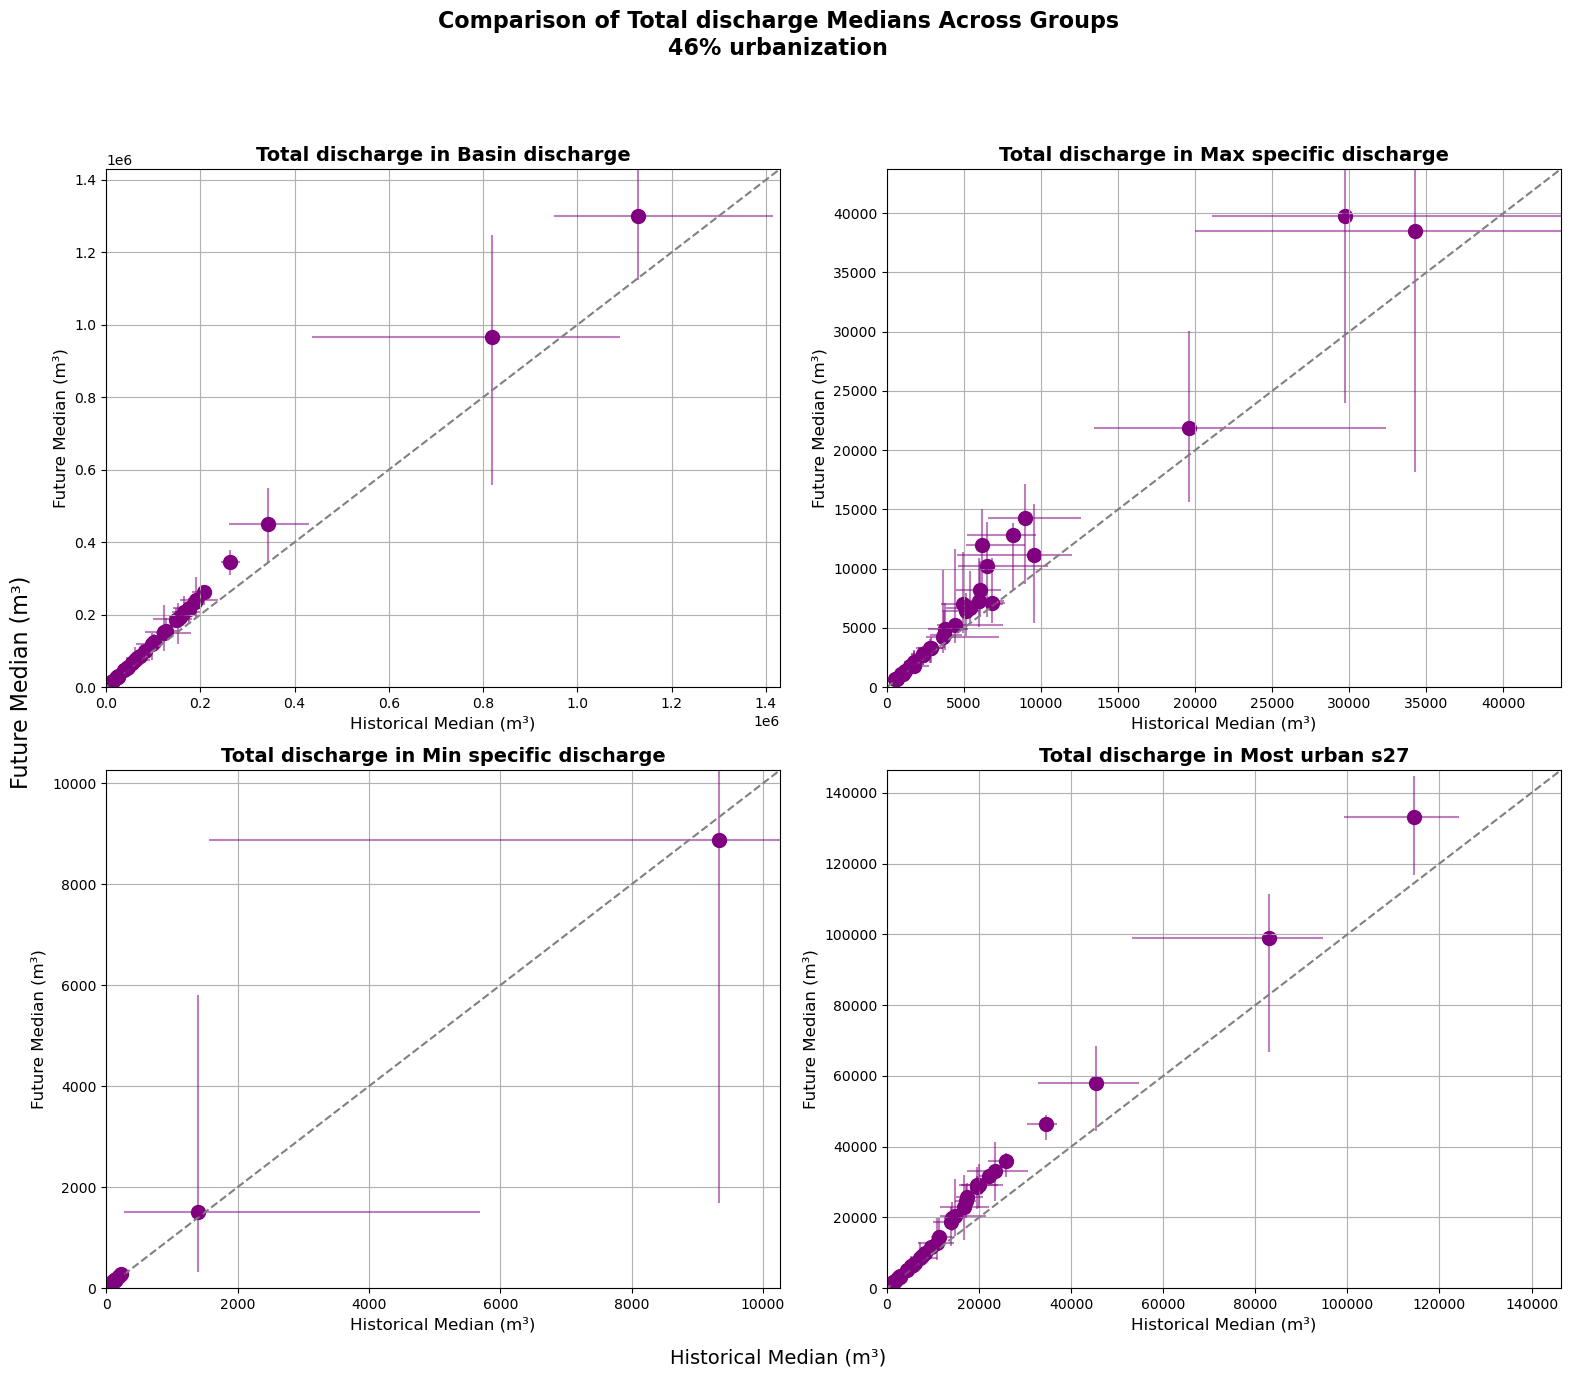

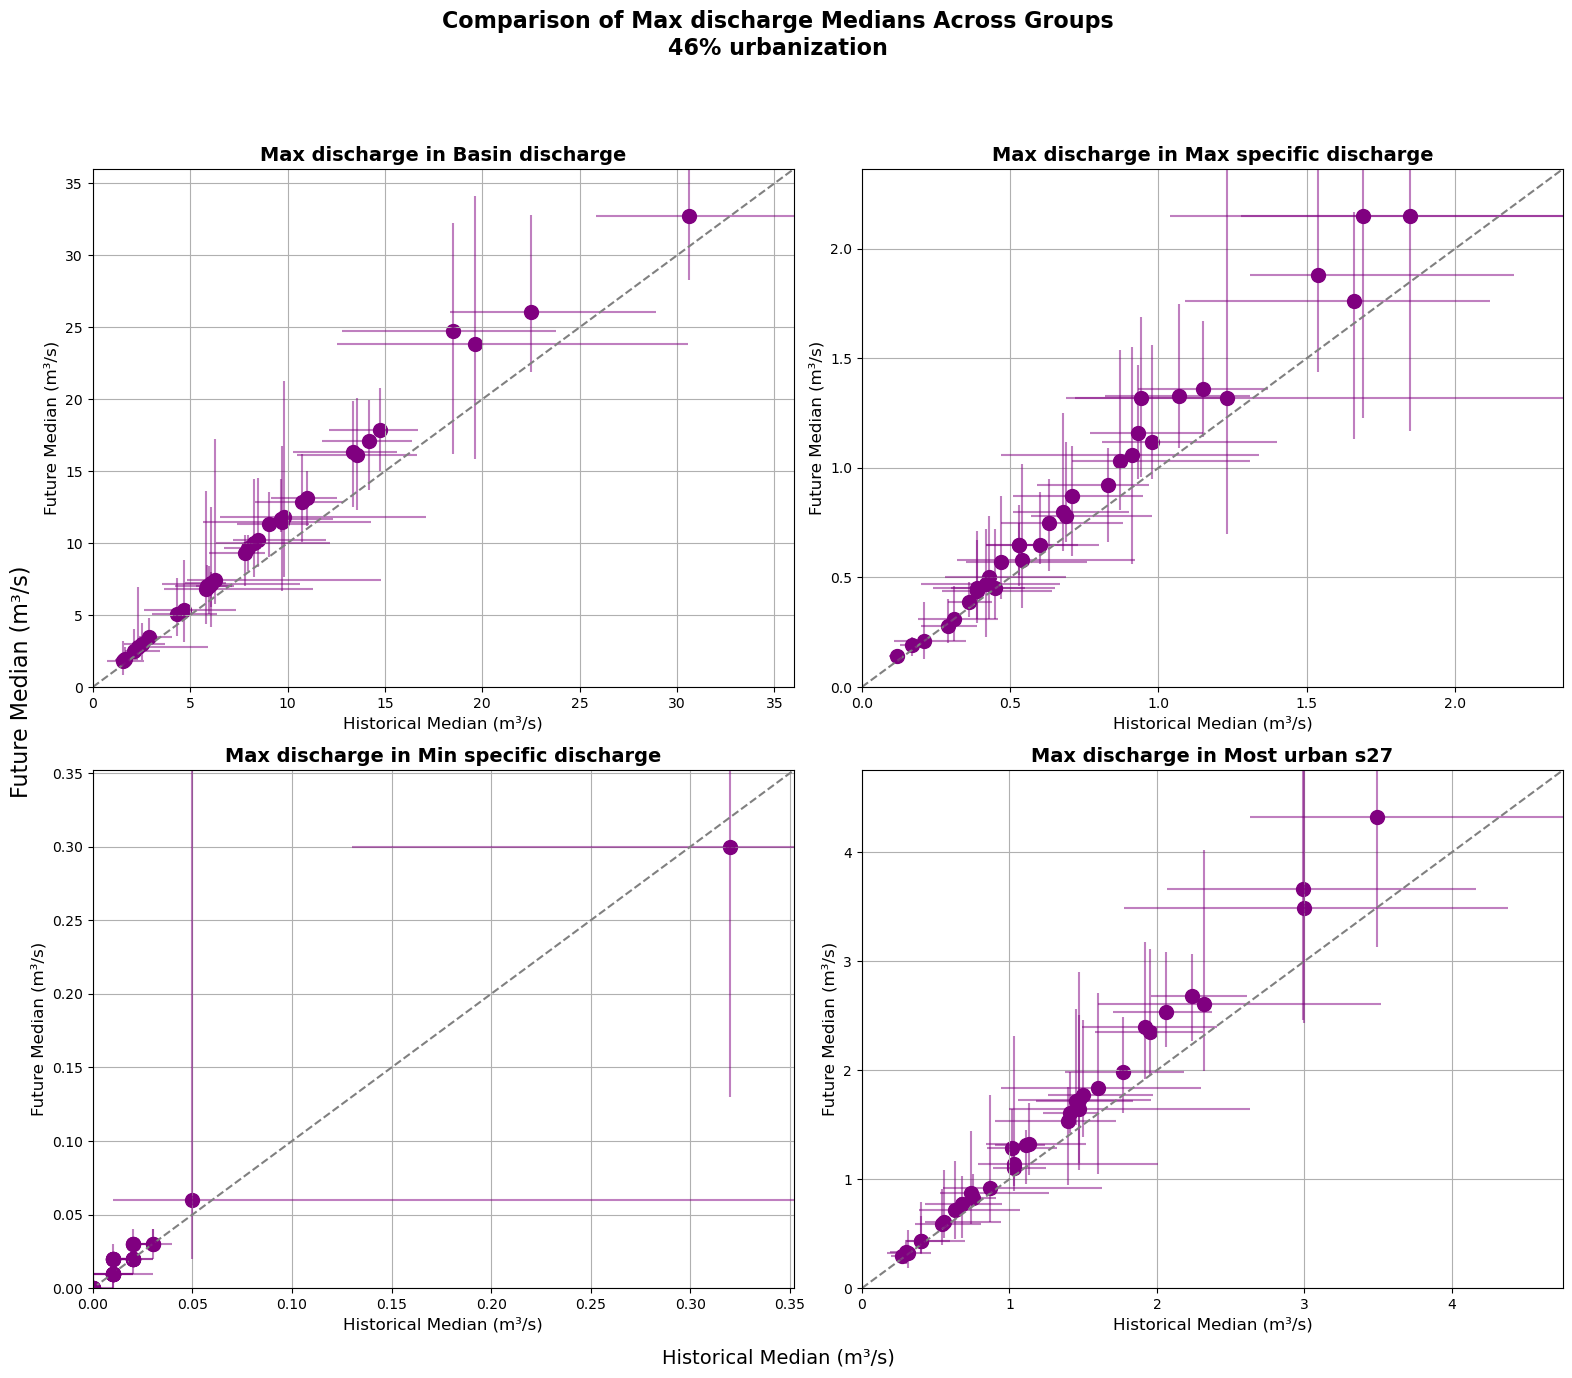

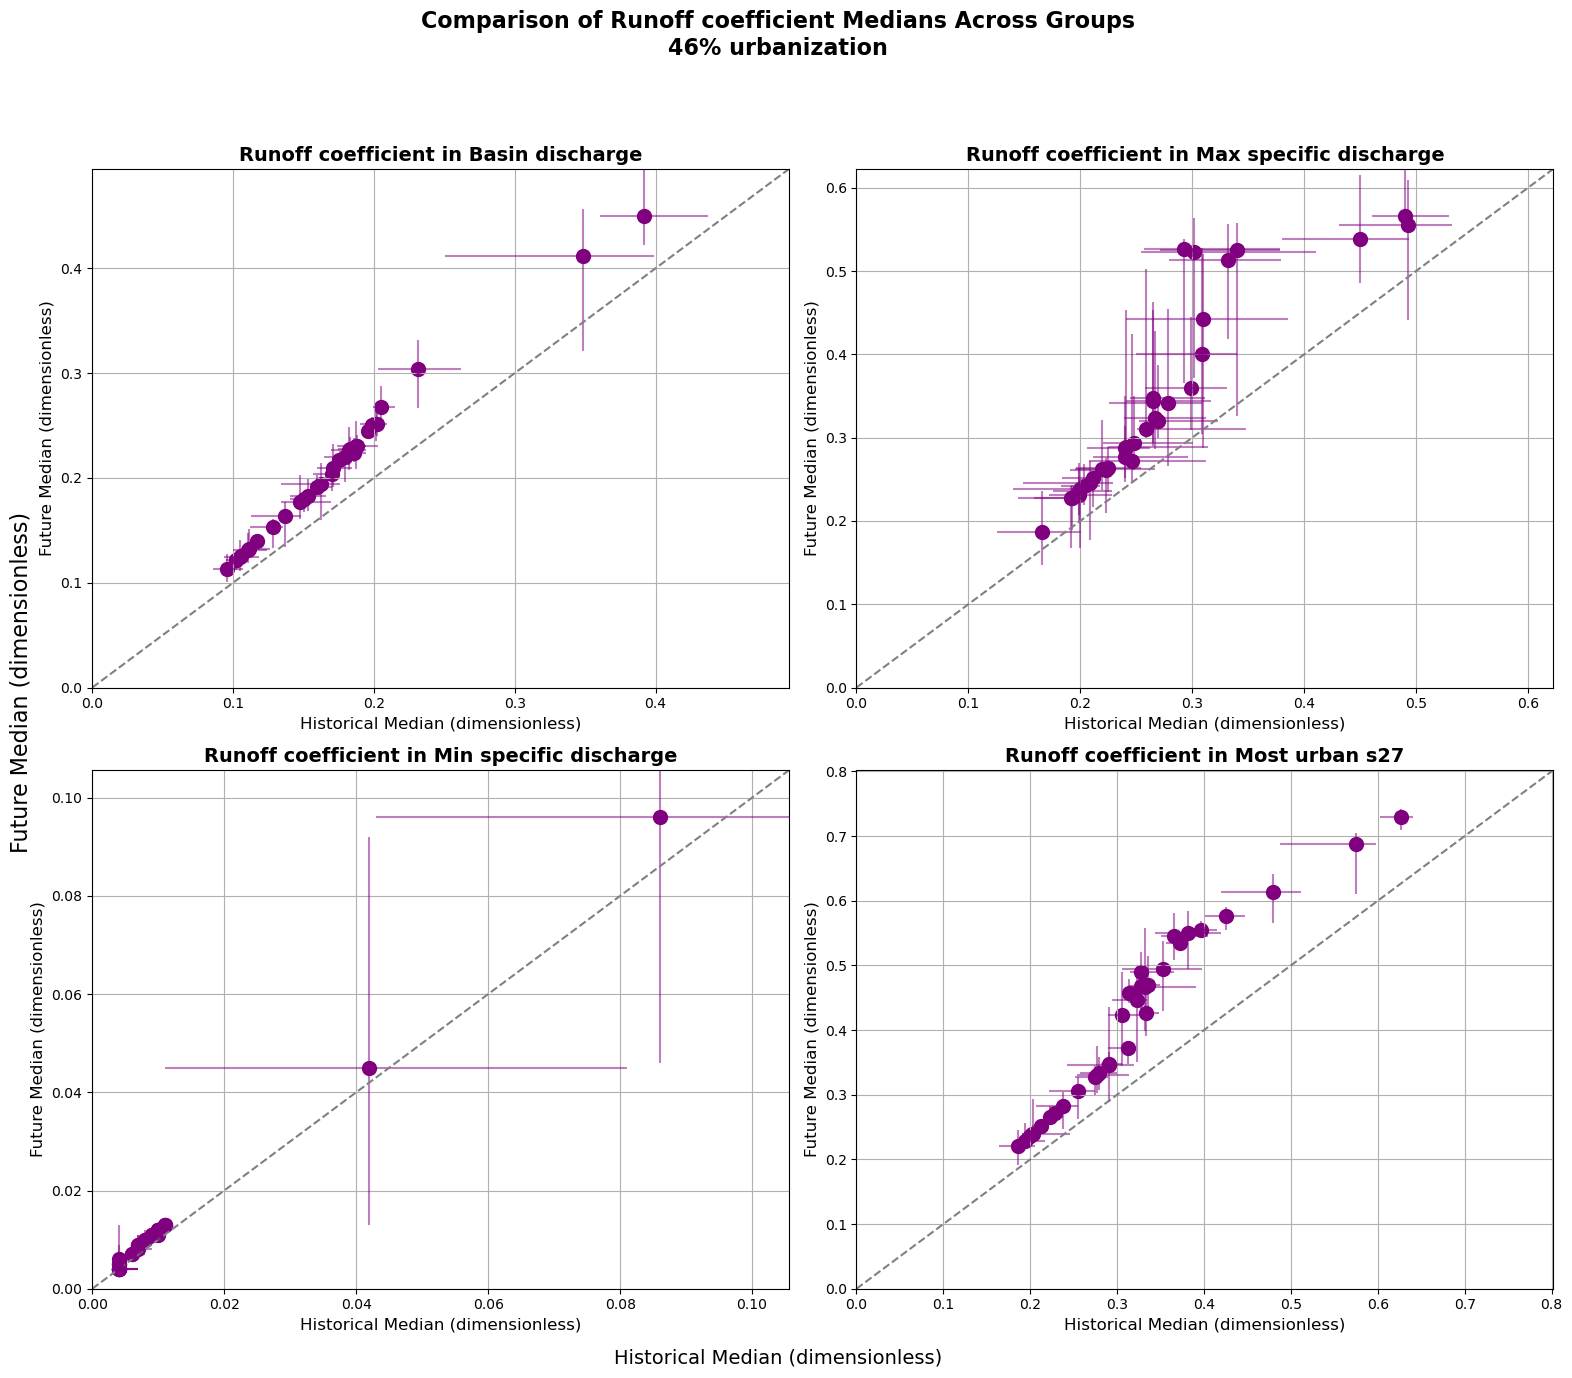

In [8]:
# Define the groups and rain parameters
groups = ['basin discharge', 'Max_Specific_Discharge', 'Min_Specific_Discharge', 'Most_Urban_S27', 'Least_Urban_s28']
rain_parameters = {
    'total_discharge': '(m³)',
    'max_discharge': '(m³/s)',
    'runoff_coefficient': '(dimensionless)'
}

# Loop through each rain parameter
for measure, unit in rain_parameters.items():
    # Create a 2x2 figure for scatter plots
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))

    # Flatten axes for easier handling
    axes = axes.flatten()

    for idx, group in enumerate(groups[:4]):  # Ensure we only take 4 groups for the 2x2 layout
        # Melt the DataFrame for the specific group and measure
        melted_df = final_results_df.melt(
            id_vars=[('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')],
            value_vars=[
                ('historical', group, measure),
                ('future', group, measure)
            ],
            var_name=['scenario', 'group', 'measure'],
            value_name='value'
        )

        # Flatten column names for seaborn compatibility
        melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'group', 'measure', 'value']

        # Compute percentiles
        percentiles_df = melted_df.groupby(['event_num', 'scenario'])['value'].agg(
            median='median',
            q25=lambda x: np.percentile(x, 25),
            q75=lambda x: np.percentile(x, 75)
        ).reset_index()

        # Pivot for scatter plot
        pivot_df = percentiles_df.pivot(index='event_num', columns='scenario')
        pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]

        # Determine max value for both axes
        max_value = pivot_df[['median_historical', 'median_future']].max().max()*1.1


        # Add diagonal line for reference
        axes[idx].plot([0, max_value], [0, max_value], linestyle='--', color='grey', label='1:1 Line')

        # Scatter plot of historical vs future medians
        axes[idx].scatter(pivot_df['median_historical'], pivot_df['median_future'], color='purple', label='Median', s=100)

        # Add error bars for the 25th and 75th percentiles
        for _, row in pivot_df.iterrows():
            axes[idx].errorbar(row['median_historical'], row['median_future'],
                               xerr=[[row['median_historical'] - row['q25_historical']],
                                     [row['q75_historical'] - row['median_historical']]],
                               yerr=[[row['median_future'] - row['q25_future']],
                                     [row['q75_future'] - row['median_future']]],
                               fmt='o', color='purple', alpha=0.5)

        # Set labels, title, and axis limits
        axes[idx].set_title(f'{measure.capitalize().replace("_", " ")} in {group.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel(f'Historical Median {unit}', fontsize=12)
        axes[idx].set_ylabel(f'Future Median {unit}', fontsize=12)
        axes[idx].grid(True)
        axes[idx].set_xlim(0, max_value)
        axes[idx].set_ylim(0, max_value)

    # Add shared labels
    fig.supxlabel(f'Historical Median {unit}', fontsize=14)
    fig.supylabel(f'Future Median {unit}', fontsize=16)

    # Add a main title for the figure
    fig.suptitle(f'Comparison of {measure.capitalize().replace("_", " ")} Medians Across Groups\n{rain_shift_classes[rain_shift_idx][1]}', fontsize=16, fontweight='bold', y=0.98)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    # Save the figure
#     plt.savefig(os.path.join(save_dir, f'scatterplot_median_{measure}.png'))
    plt.show()


# All events boxplot

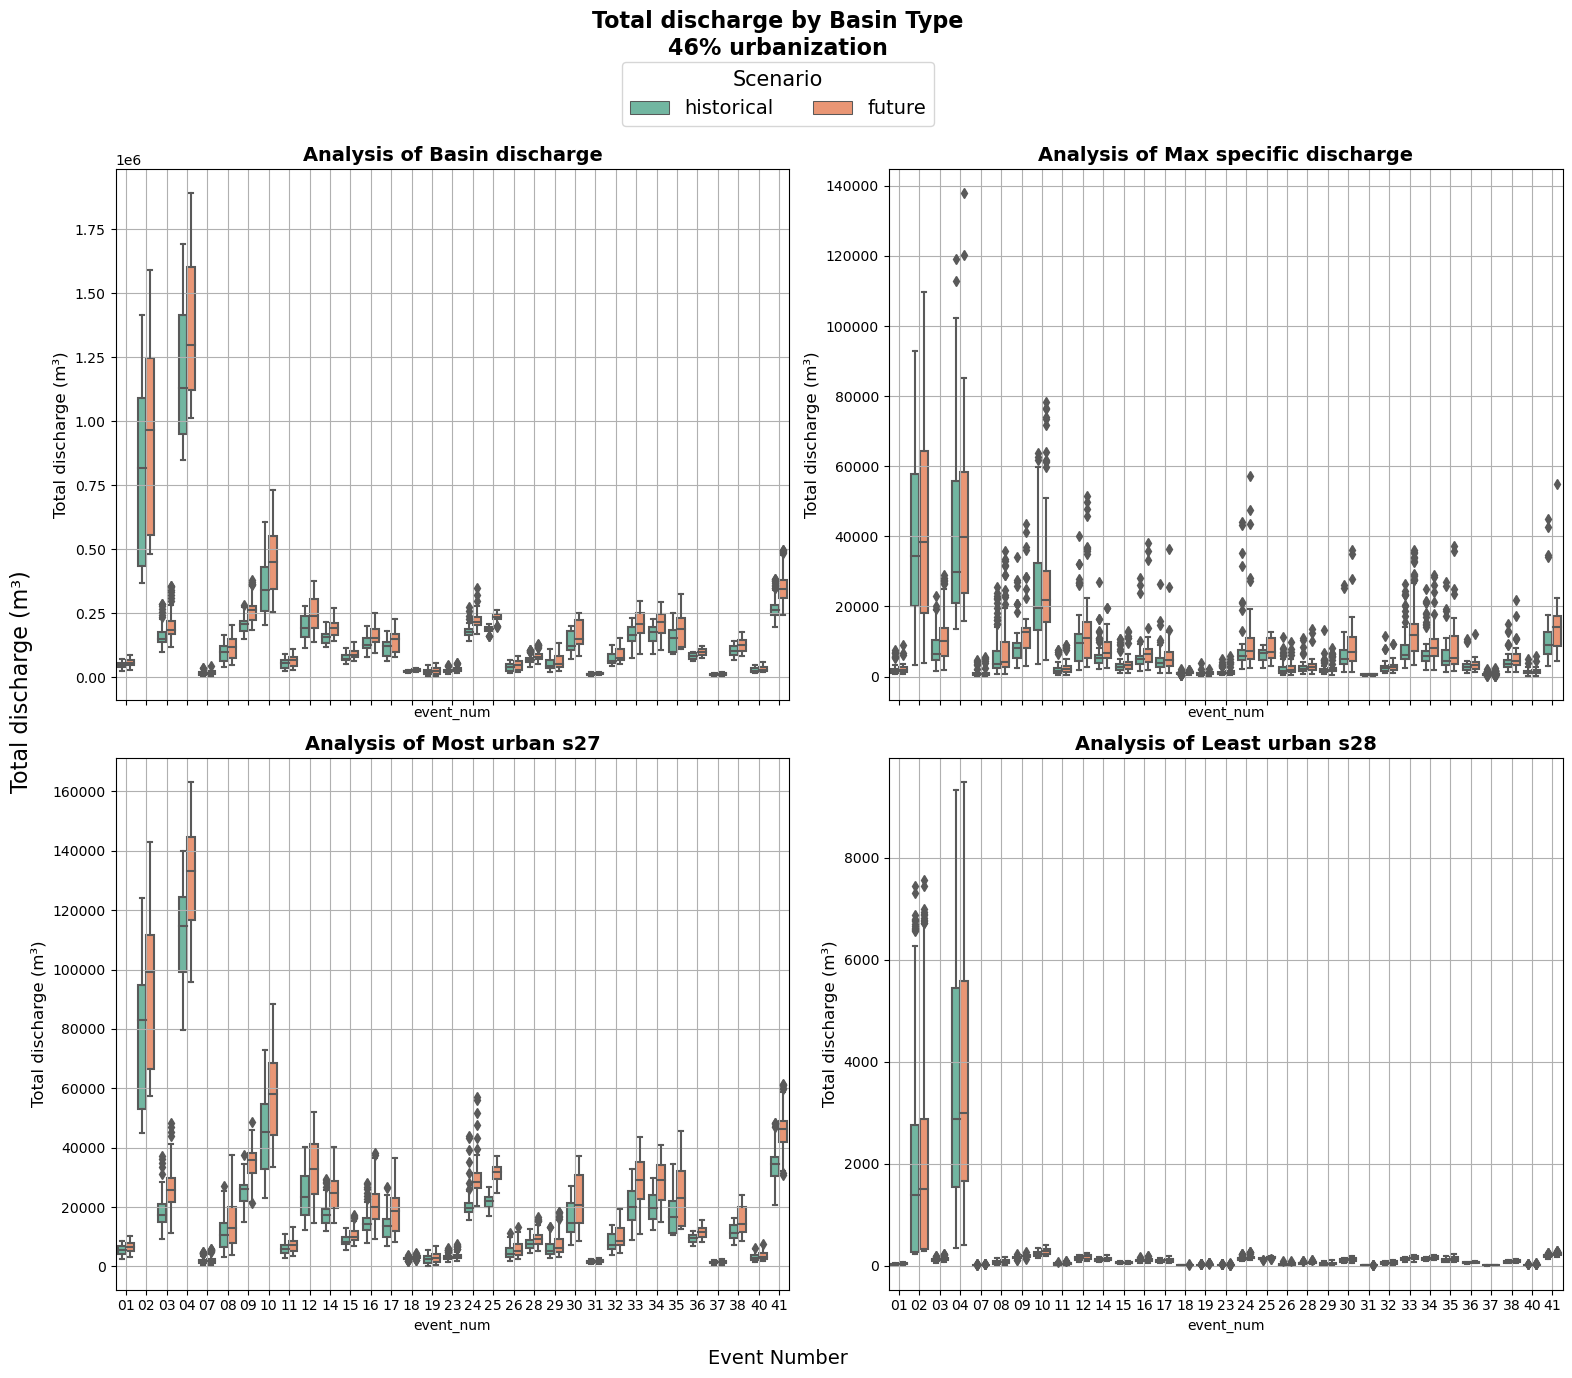

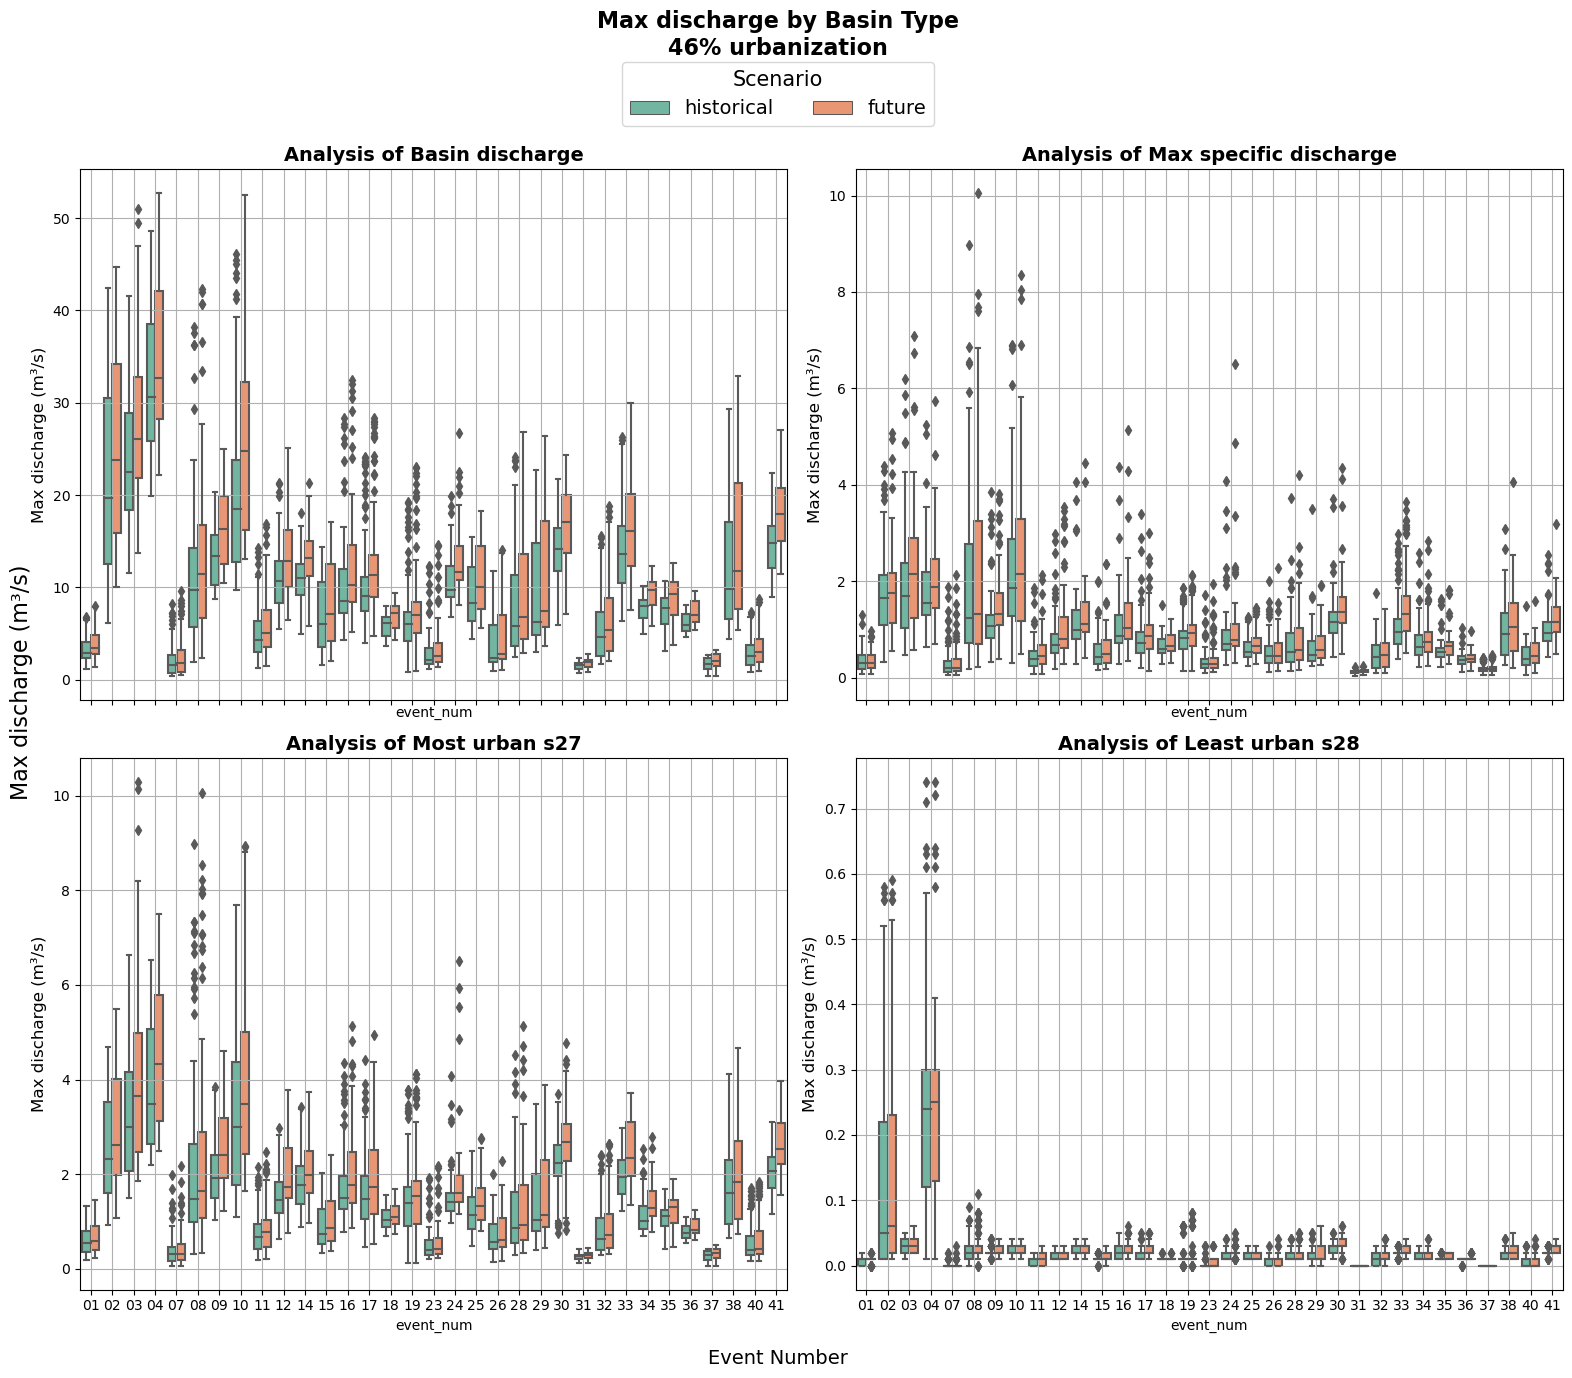

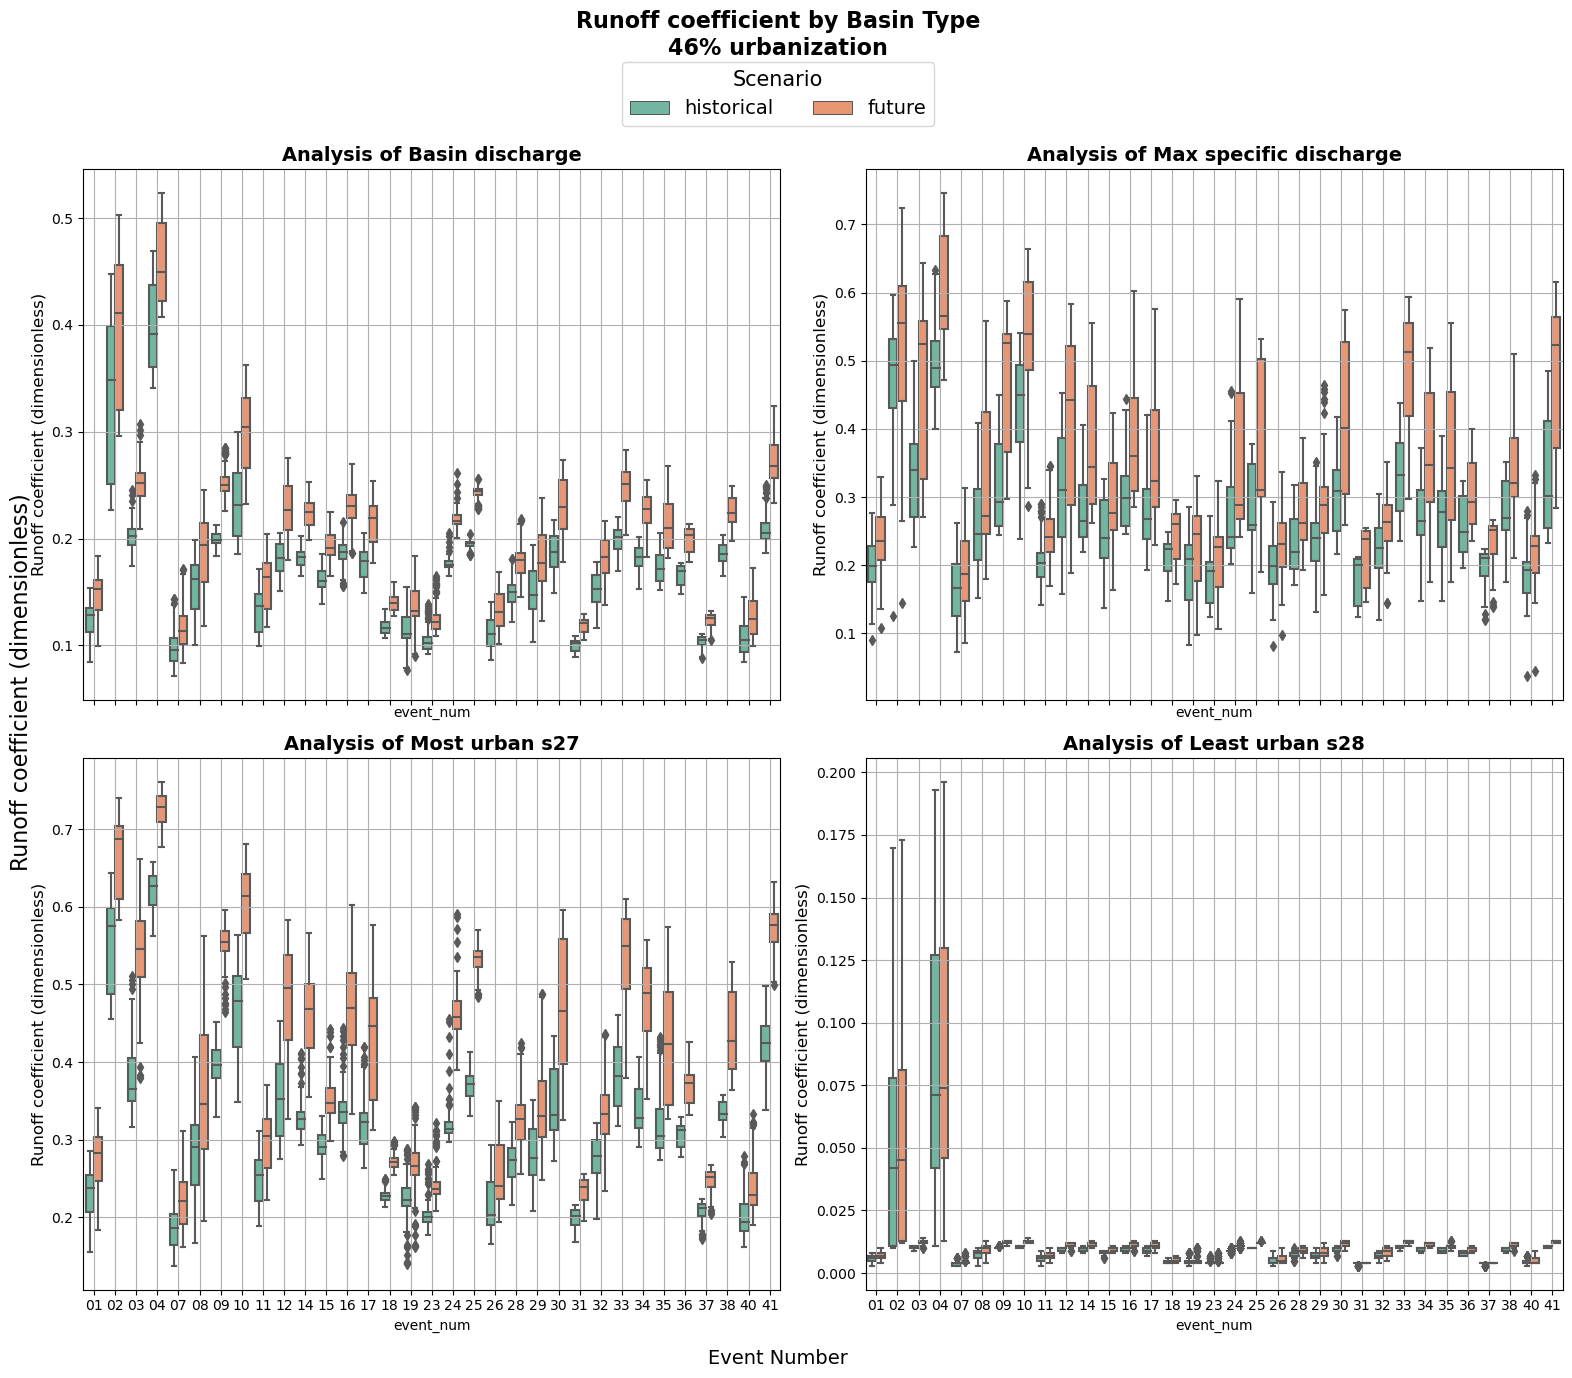

In [9]:
# Define the groups and rain parameters
groups = ['basin discharge', 'Max_Specific_Discharge', 'Most_Urban_S27', 'Least_Urban_S28']
rain_parameters = {
    'total_discharge': '(m³)',
    'max_discharge': '(m³/s)',
    'runoff_coefficient': '(dimensionless)'
}

# Loop through each rain parameter
for measure, unit in rain_parameters.items():
    # Create a 2x2 figure for each graph type
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14), sharex=True)

    # Flatten axes for easier handling
    axes = axes.flatten()

    for idx, group in enumerate(groups):
        # Melt the DataFrame for the specific group and measure
        melted_df = final_results_df.melt(
            id_vars=[('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')],
            value_vars=[
                ('historical', group, measure),
                ('future', group, measure)
            ],
            var_name=['scenario', 'group', 'measure'],
            value_name='value'
        )

        # Flatten column names for seaborn compatibility
        melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'group', 'measure', 'value']

        # **Plot 1: Boxplot**
        sns.boxplot(data=melted_df, x='event_num', y='value', hue='scenario', palette='Set2', ax=axes[idx])

        # Add labels and titles
        axes[idx].set_ylabel(f'{measure.capitalize().replace("_", " ")} {unit}', fontsize=12)
        axes[idx].set_title(f'Analysis of {group.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
        axes[idx].grid(True)

    # Remove legends from individual subplots
    for ax in axes:
        ax.legend_.remove()

    # Add shared legend above the plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, 
        title='Scenario', title_fontsize=15, fontsize=14
    )

    # Add shared X and Y labels
    fig.supxlabel('Event Number', fontsize=14)
    fig.supylabel(f'{measure.capitalize().replace("_", " ")} {unit}', fontsize=16)

    # Add a main title for the figure
    fig.suptitle(f'{measure.capitalize().replace("_", " ")} by Basin Type\n{rain_shift_classes[rain_shift_idx][1]}', fontsize=16, fontweight='bold', y=0.98)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    # Save the figure
#     plt.savefig(os.path.join(save_dir, f'subplots_2x2_{measure}.png'))
    plt.show()


# q75-q25 diff boxplot
אפשר לראות שבאישבאירועים העתידיים יש שונות הרבה יותר גדולה.האם זה יכול להצביע על שונות מרחבית בסופה? 

c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


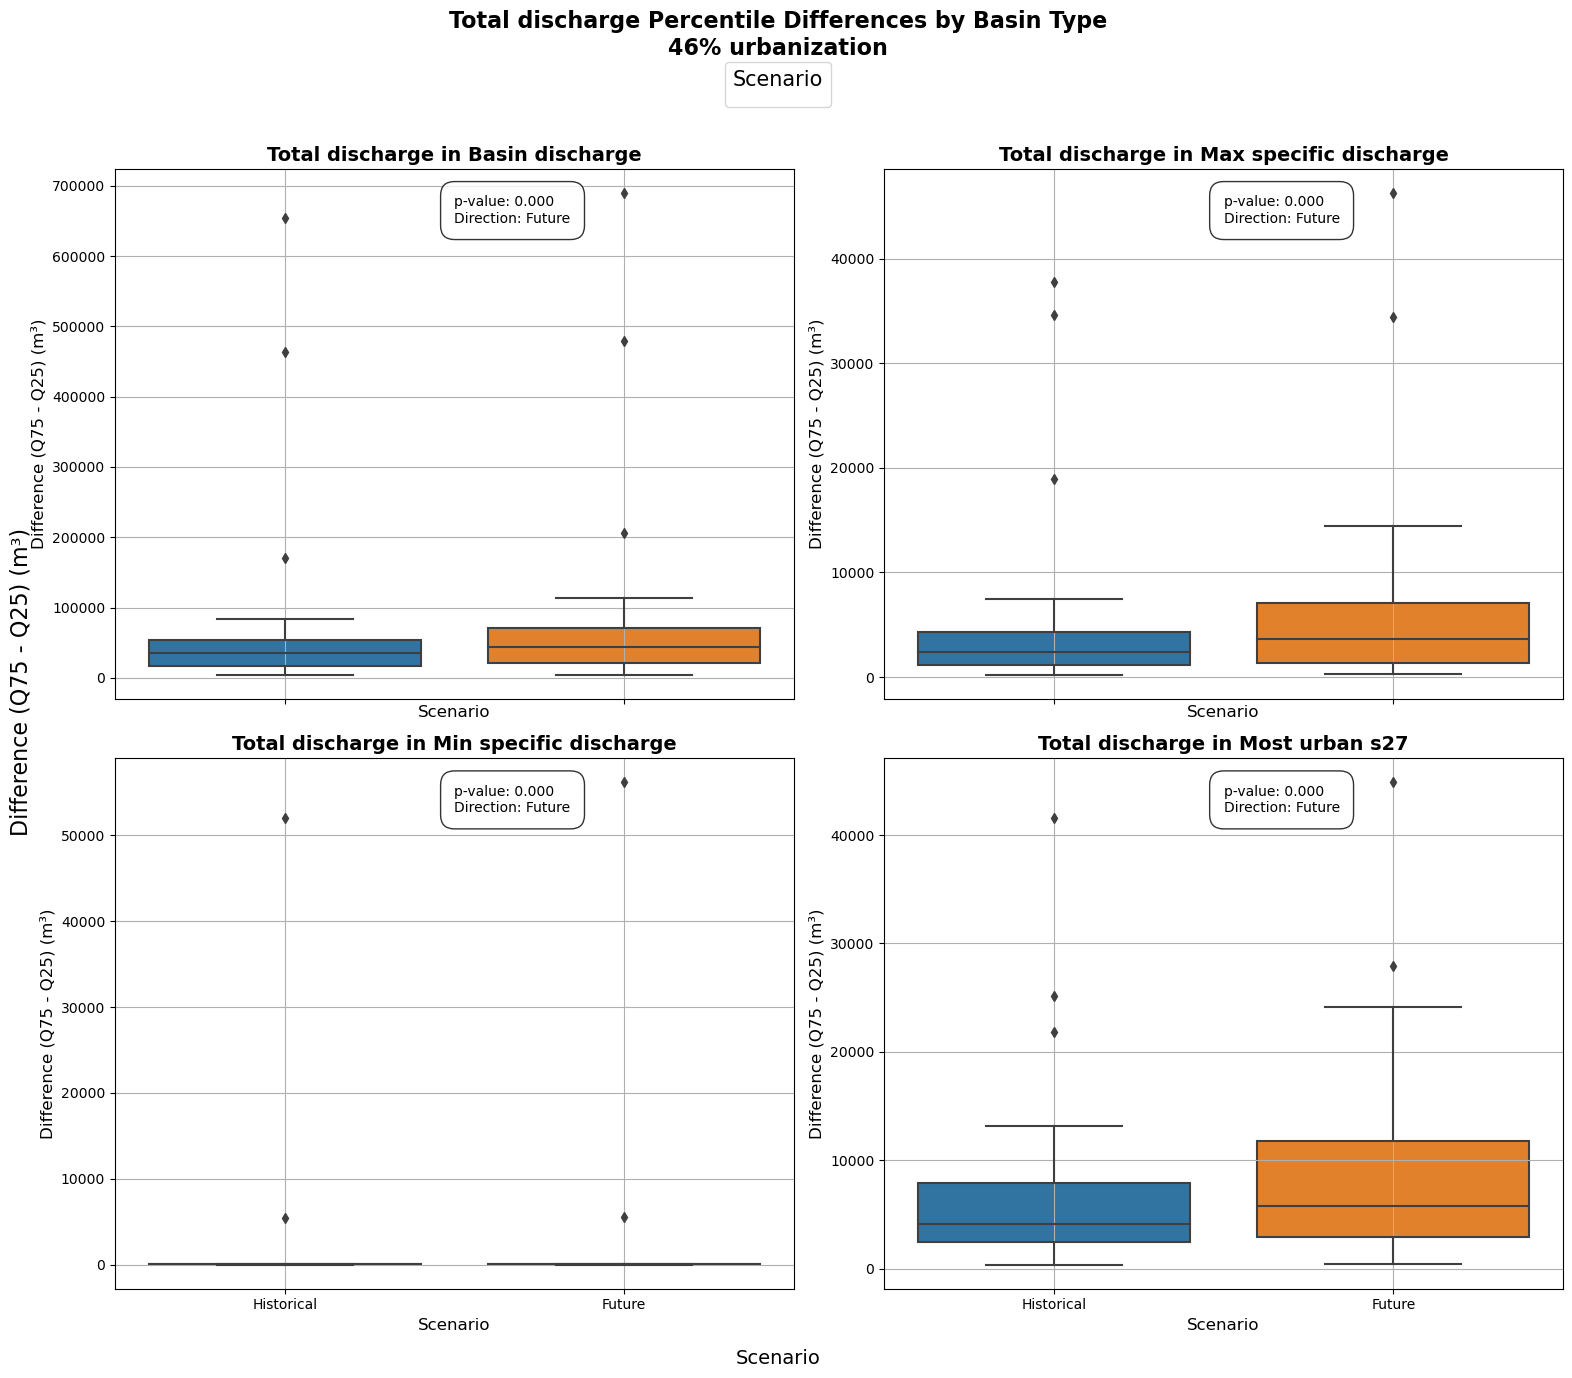

c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


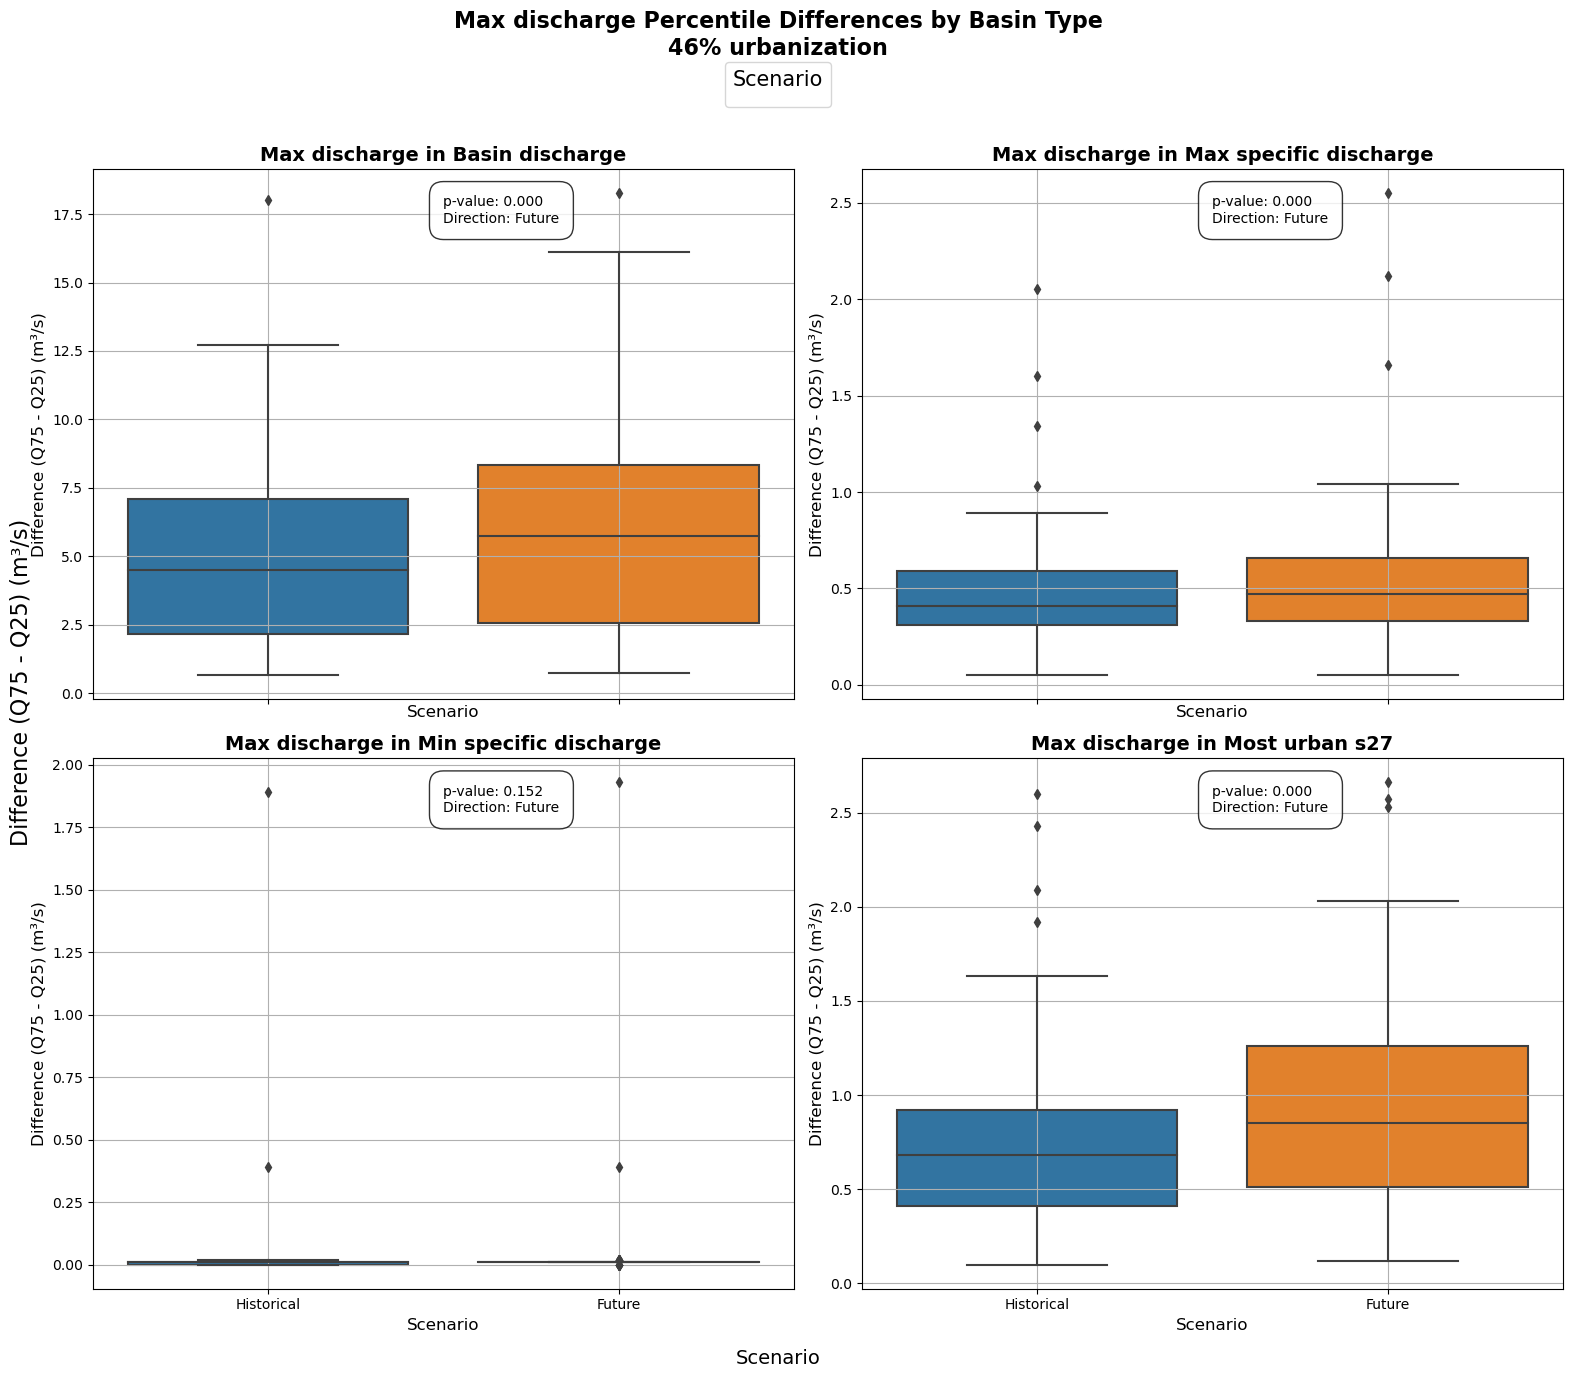

c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


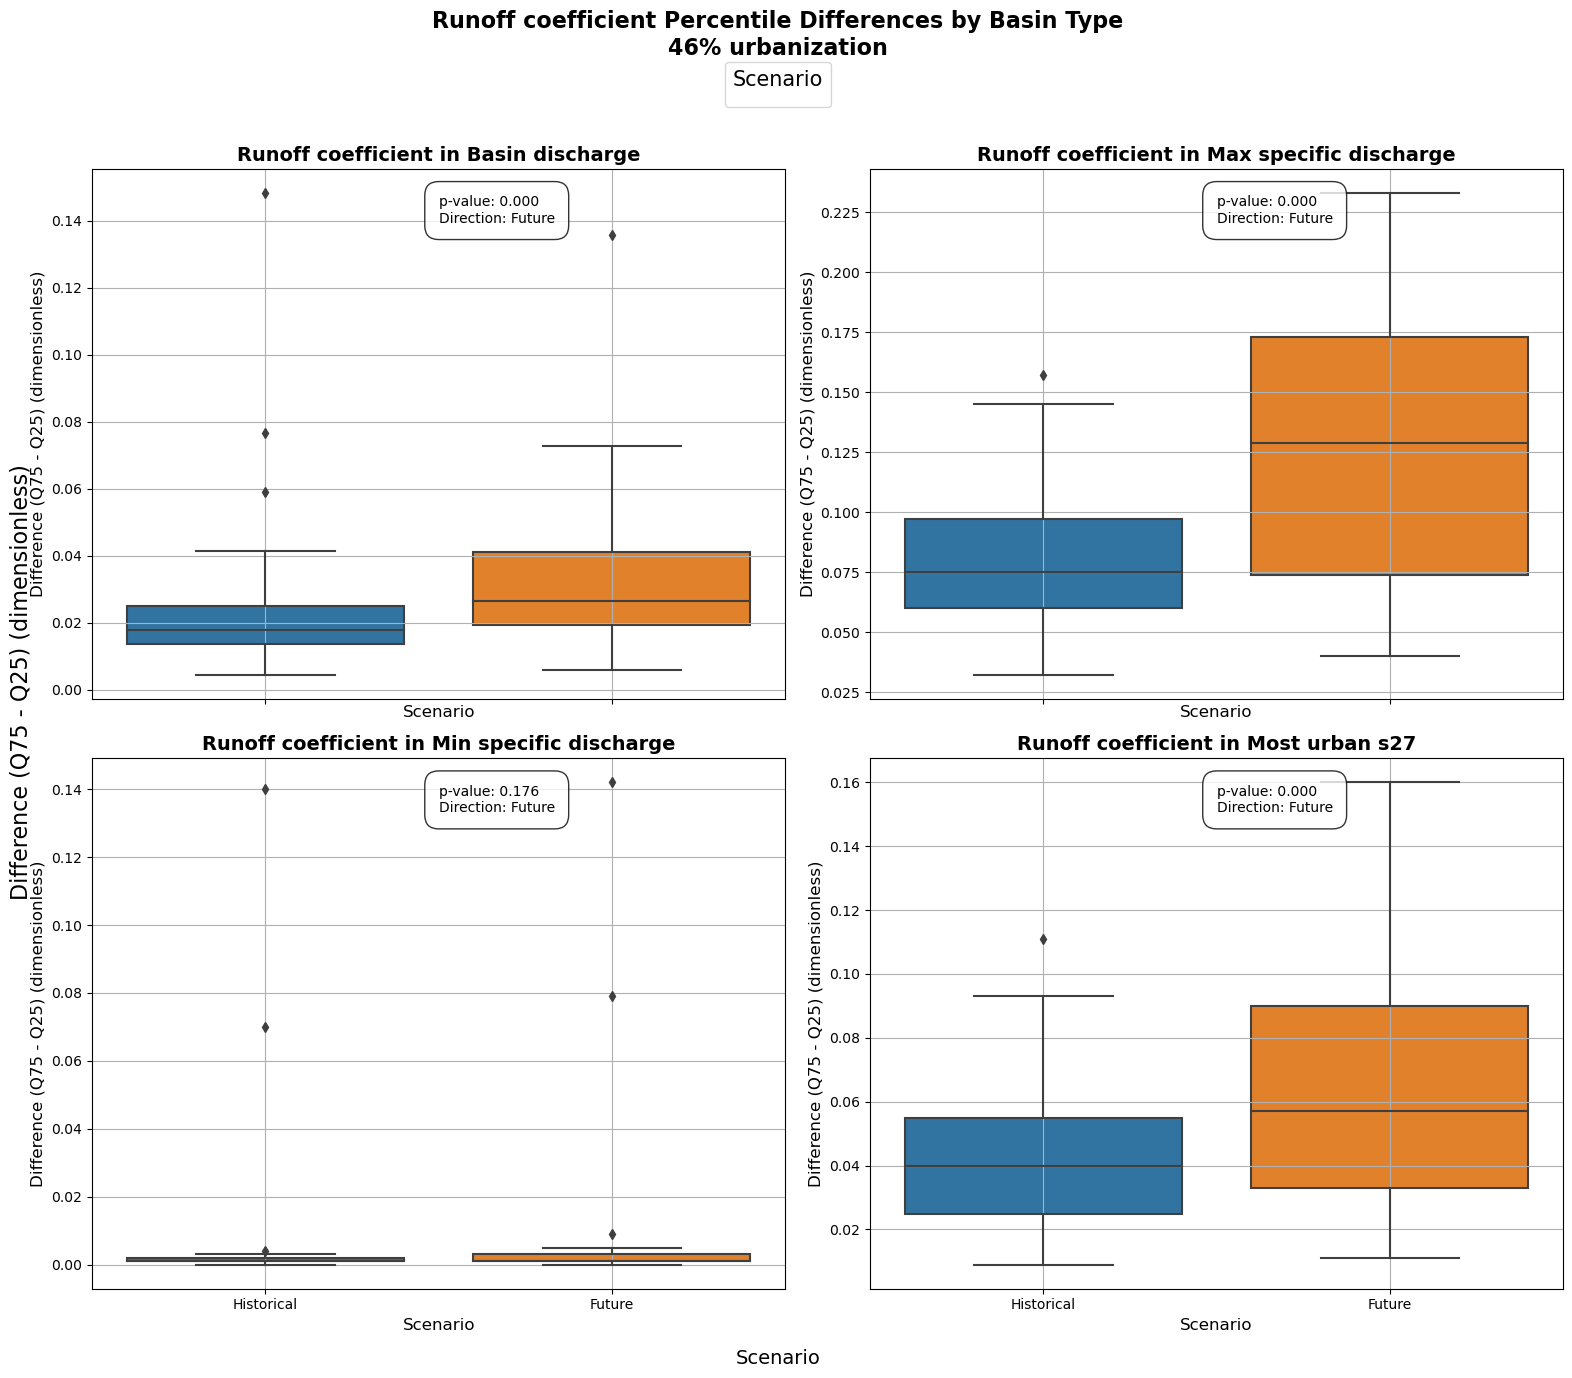

In [10]:
# Define the groups and rain parameters
groups = ['basin discharge', 'Max_Specific_Discharge', 'Min_Specific_Discharge', 'Most_Urban_S27', 'Least_Urban_s28']
rain_parameters = {
    'total_discharge': '(m³)',
    'max_discharge': '(m³/s)',
    'runoff_coefficient': '(dimensionless)'
}

# Loop through each rain parameter
for measure, unit in rain_parameters.items():
    # Create a 2x2 figure for each graph type
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14), sharex=True)

    # Flatten axes for easier handling
    axes = axes.flatten()

    for idx, group in enumerate(groups[:4]):  # Ensure we only take 4 groups for the 2x2 layout
        # Melt the DataFrame for the specific group and measure
        melted_df = final_results_df.melt(
            id_vars=[('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')],
            value_vars=[
                ('historical', group, measure),
                ('future', group, measure)
            ],
            var_name=['scenario', 'group', 'measure'],
            value_name='value'
        )

        # Flatten column names for seaborn compatibility
        melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'group', 'measure', 'value']

        # Compute the median, 25th, and 75th percentiles for each event and scenario
        percentiles_df = melted_df.groupby(['event_num', 'scenario'])['value'].agg(
            median='median',
            q25=lambda x: np.percentile(x, 25),
            q75=lambda x: np.percentile(x, 75)
        ).reset_index()

        # Pivot the DataFrame to get historical and future percentiles in separate columns
        pivot_df = percentiles_df.pivot(index='event_num', columns='scenario')
        pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]

        # Compute differences
        q_historical_diff = pivot_df['q75_historical'] - pivot_df['q25_historical']
        q_future_diff = pivot_df['q75_future'] - pivot_df['q25_future']

        # Prepare data for visualization
        diff_df = pd.DataFrame({
            'Historical': q_historical_diff,
            'Future': q_future_diff
        })

        # **Plot the boxplot in the respective subplot**
        sns.boxplot(data=diff_df, ax=axes[idx])

        # Add labels and titles
        axes[idx].set_ylabel(f'Difference (Q75 - Q25) {unit}', fontsize=12)
        axes[idx].set_title(f'{measure.capitalize().replace("_", " ")} in {group.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Scenario', fontsize=12)
        axes[idx].grid(True)

        # Add Wilcoxon test results as text
        stat, p_value = wilcoxon(q_historical_diff, q_future_diff)
        mean_diff_direction = "Historical" if diff_df['Historical'].mean() > diff_df['Future'].mean() else "Future"
        axes[idx].text(0.5, 0.95, f'p-value: {p_value:.3f}\nDirection: {mean_diff_direction}',
                       transform=axes[idx].transAxes, fontsize=10, verticalalignment='top',
                       bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=1'))

    # Remove any empty subplots (if groups < total subplots)
    for ax_idx in range(len(groups[:4]), len(axes)):
        fig.delaxes(axes[ax_idx])

    # Add a shared legend above the plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, 
        title='Scenario', title_fontsize=15, fontsize=14
    )

    # Add shared X and Y labels
    fig.supxlabel('Scenario', fontsize=14)
    fig.supylabel(f'Difference (Q75 - Q25) {unit}', fontsize=16)

    # Add a main title for the figure
    fig.suptitle(f'{measure.capitalize().replace("_", " ")} Percentile Differences by Basin Type\n{rain_shift_classes[rain_shift_idx][1]}', fontsize=16, fontweight='bold', y=0.98)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    # Save the figure
#     plt.savefig(os.path.join(save_dir, f'subplots_diff_Q75_Q25_{measure}.png'))
    plt.show()


# Rain inten Vs discharge

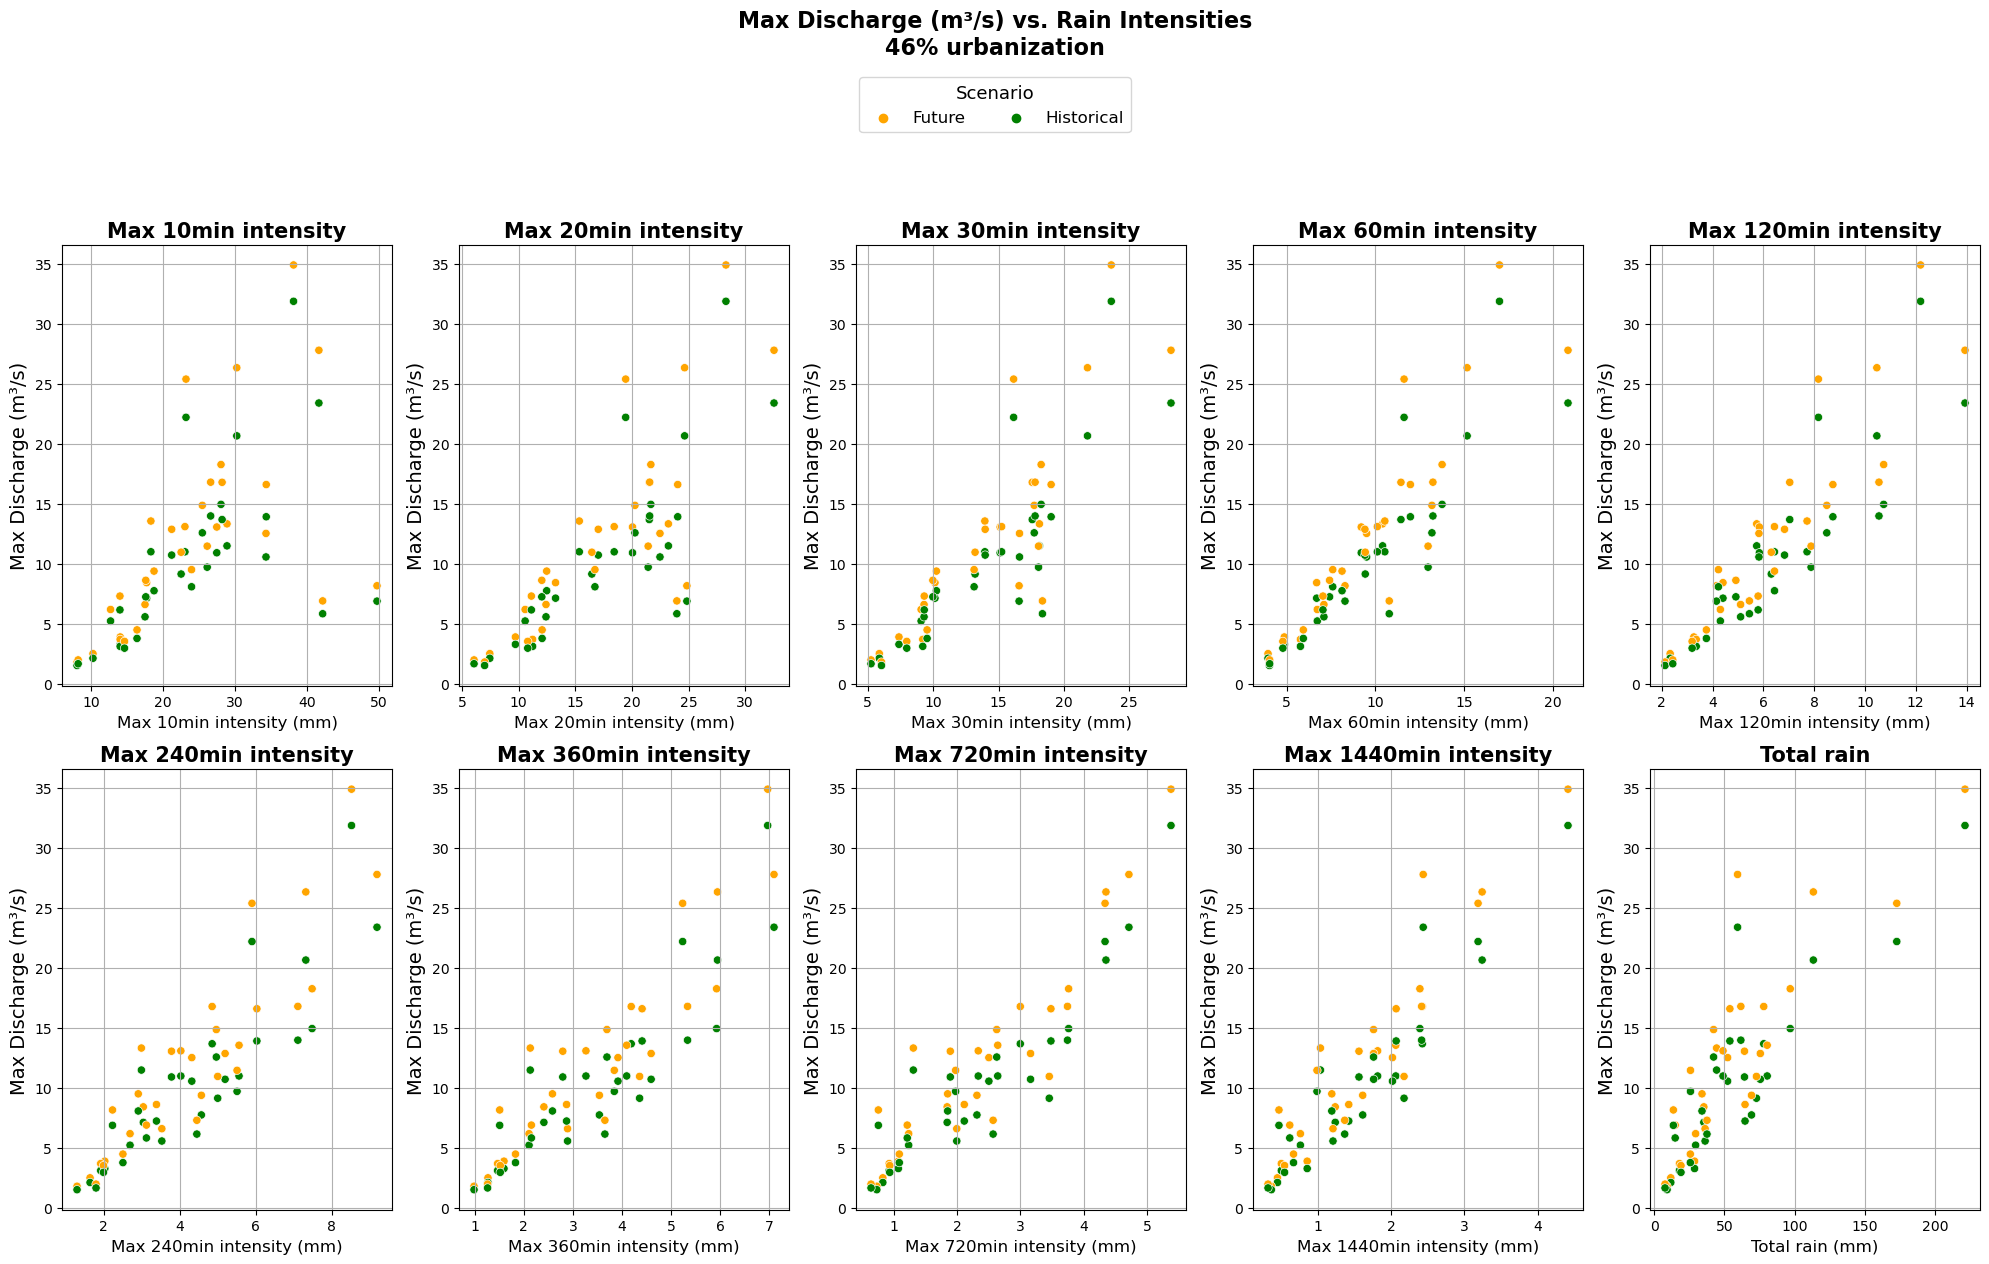

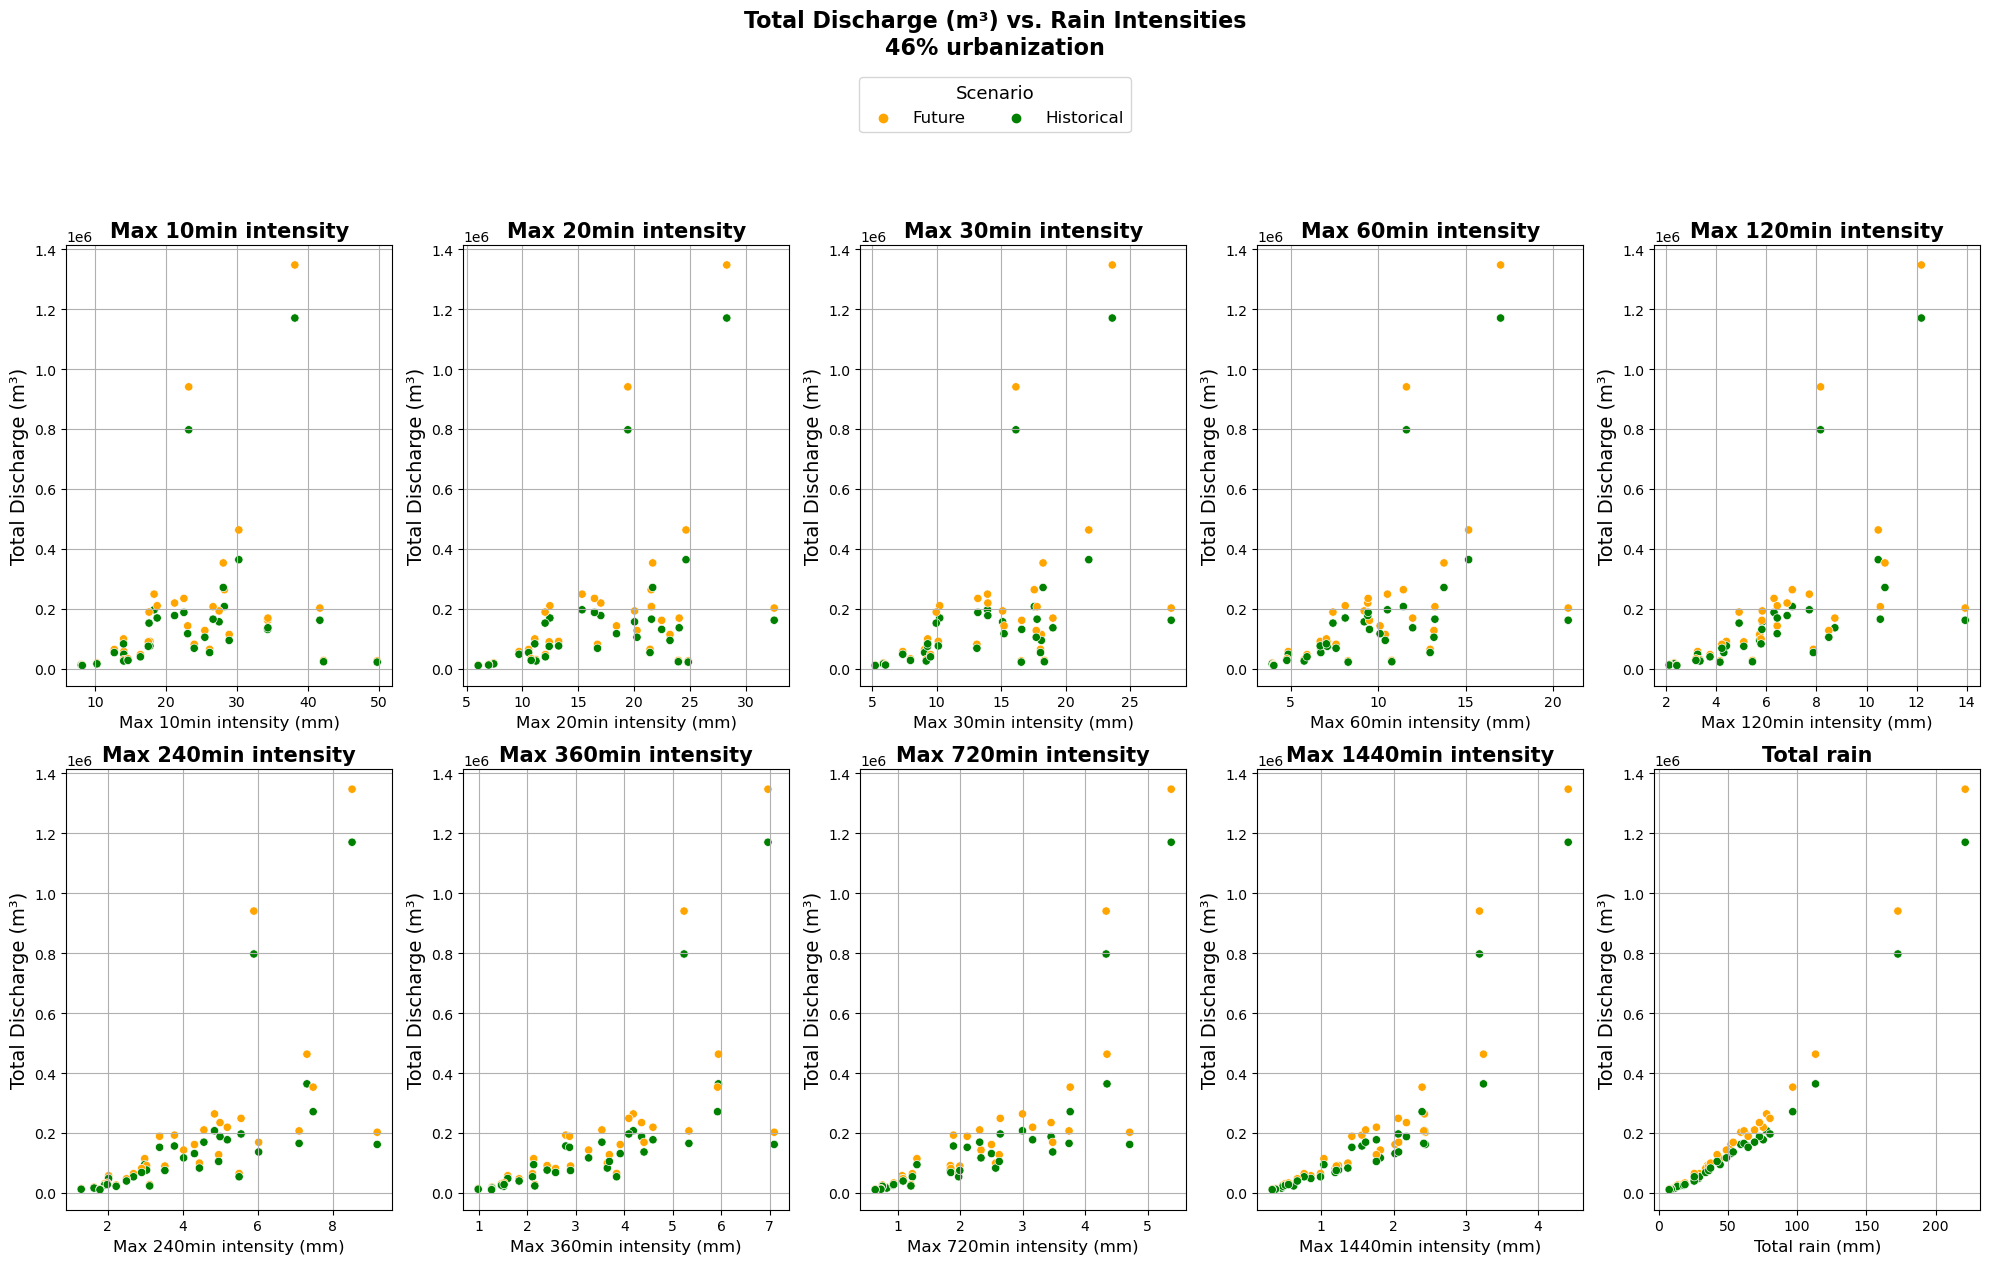

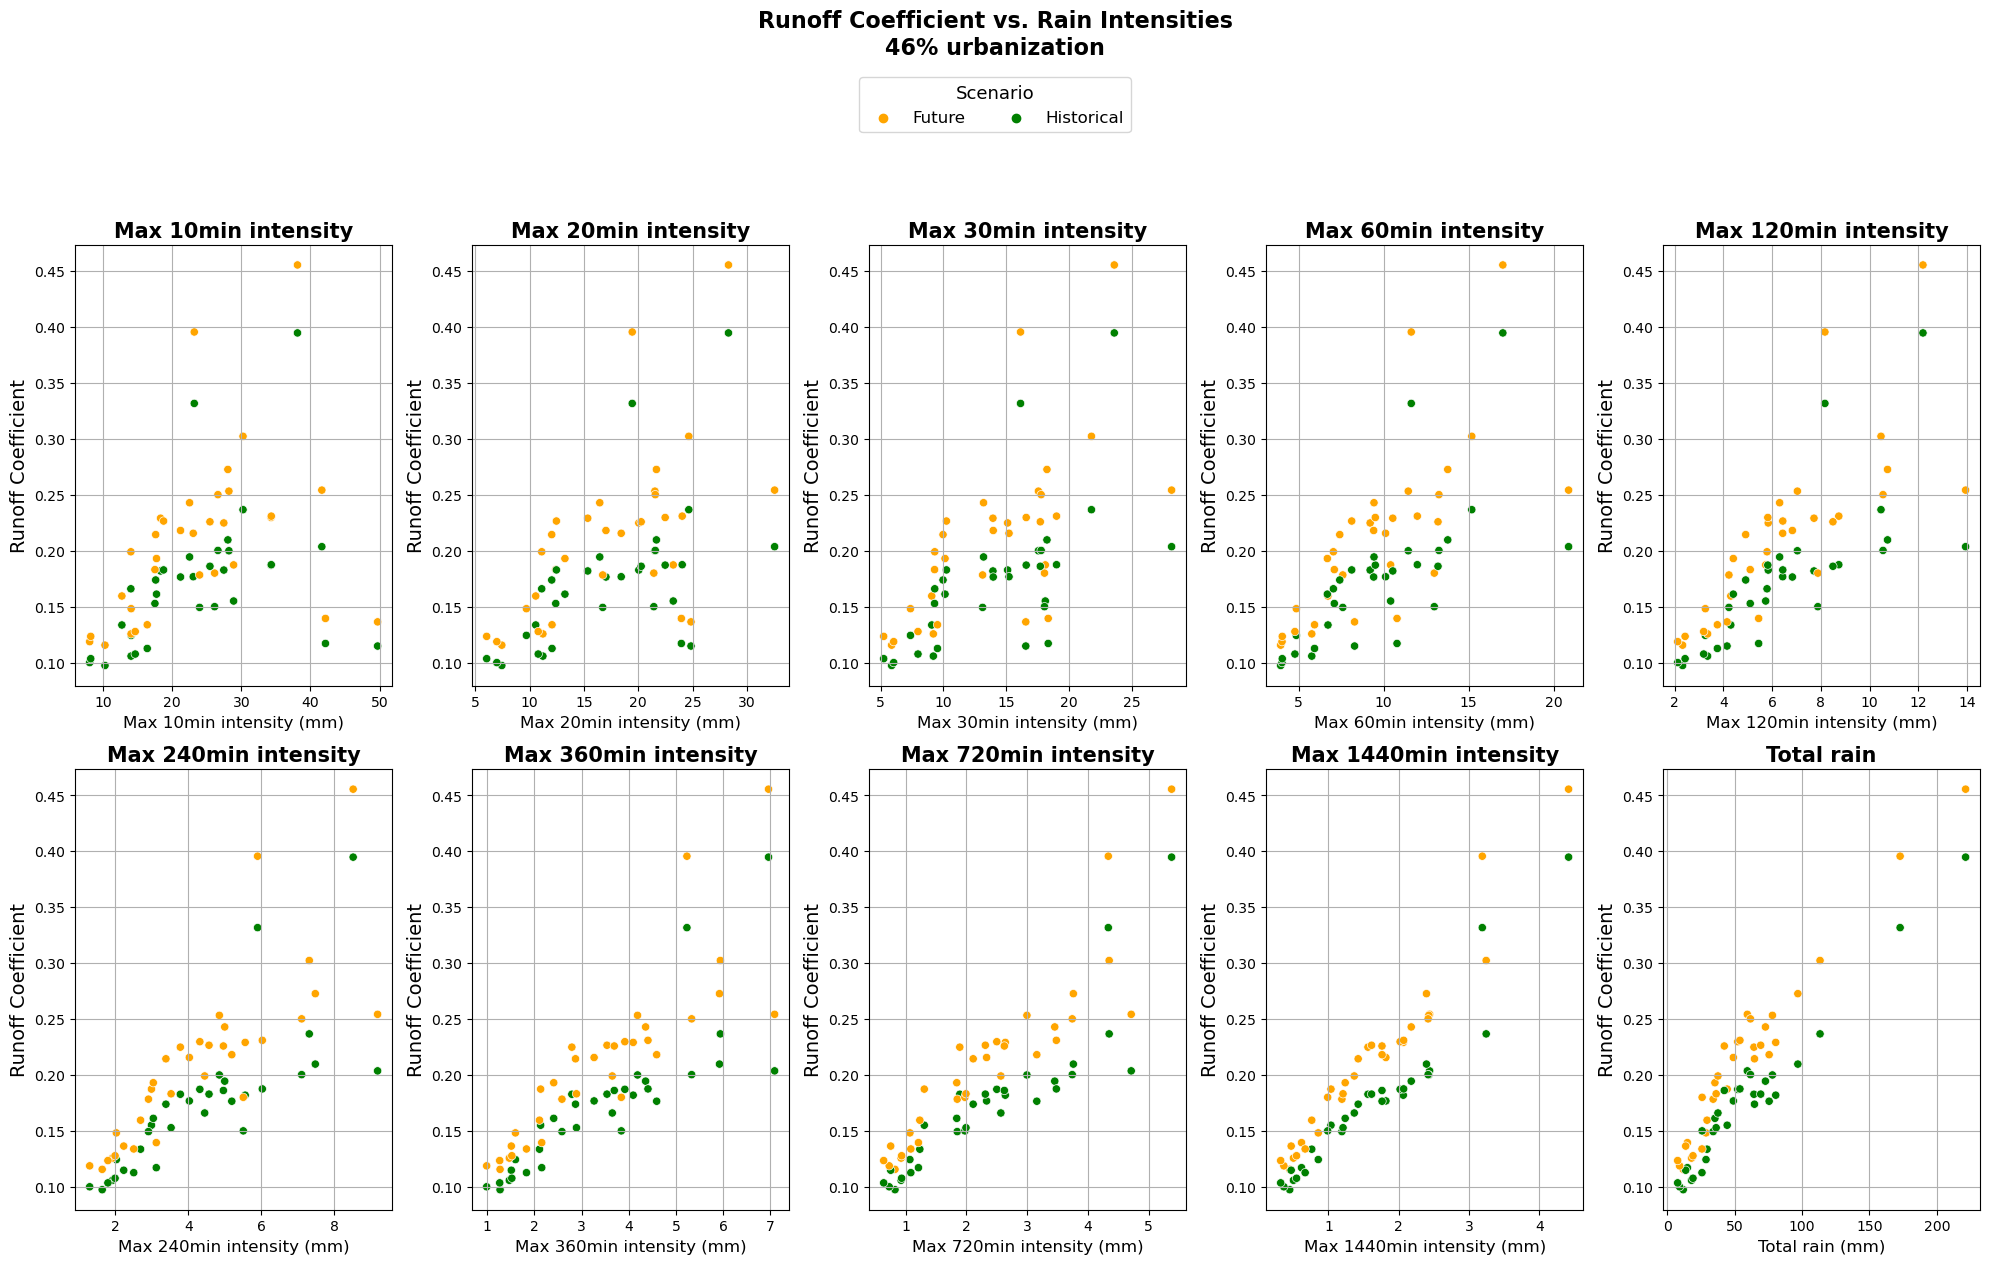

In [11]:
# Define the Y-axis variables and their titles
y_columns = {
    ('basin discharge', 'max_discharge'): 'Max Discharge (m³/s)',
    ('basin discharge', 'total_discharge'): 'Total Discharge (m³)',
    ('basin discharge', 'runoff_coefficient'): 'Runoff Coefficient'
}

# Define the intensities for the X-axis
intensity_columns = [
    ('historical', 'full_basin', 'max_10min_intensity'),
    ('historical', 'full_basin', 'max_20min_intensity'),
    ('historical', 'full_basin', 'max_30min_intensity'),
    ('historical', 'full_basin', 'max_60min_intensity'),
    ('historical', 'full_basin', 'max_120min_intensity'),
    ('historical', 'full_basin', 'max_240min_intensity'),
    ('historical', 'full_basin', 'max_360min_intensity'),
    ('historical', 'full_basin', 'max_720min_intensity'),
    ('historical', 'full_basin', 'max_1440min_intensity'),
    ('historical', 'full_basin', 'total_rain')
]

# Custom colors
custom_palette = {'Historical': 'green', 'Future': 'orange'}

# Loop through each Y-axis variable
for y_col, y_label in y_columns.items():
    # Create the figure
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 12))  # 10 subplots
    axes = axes.flatten()

    # Loop through intensity columns and plot
    for idx, intensity_col in enumerate(intensity_columns):
        ax = axes[idx]

        # Extract the relevant data for historical and future
        historical_data = final_results_df.loc[:, [('event_num', '', ''), 
                                                   ('historical', y_col[0], y_col[1]), intensity_col]]
        historical_data.columns = ['event_num', 'y_value', 'intensity']
        historical_data['scenario'] = 'Historical'

        future_data = final_results_df.loc[:, [('event_num', '', ''), 
                                               ('future', y_col[0], y_col[1]), 
                                               ('future', intensity_col[1], intensity_col[2])]]
        future_data.columns = ['event_num', 'y_value', 'intensity']
        future_data['scenario'] = 'Future'

        # Combine historical and future data
        combined_data = pd.concat([historical_data, future_data])

        # Group by event_num and scenario to calculate the mean
        mean_data = combined_data.groupby(['event_num', 'scenario']).mean().reset_index()

        # Scatter plot
        sns.scatterplot(data=mean_data, x='intensity', y='y_value', hue='scenario', palette=custom_palette, ax=ax)

        # Set labels and title
        ax.set_title(f'{intensity_col[2].replace("_", " ").capitalize()}', fontsize=15, fontweight='bold')
        ax.set_xlabel(f'{intensity_col[2].replace("_", " ").capitalize()} (mm)', fontsize=12)
        ax.set_ylabel(y_label, fontsize=14)
        ax.grid(True)

        # Remove individual legends
        ax.legend_.remove()

    # Add a shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=2, title='Scenario', fontsize=12, title_fontsize=13)

    # Add main title
    fig.suptitle(f'{y_label} vs. Rain Intensities\n{rain_shift_classes[rain_shift_idx][1]}', fontsize=16, fontweight='bold', y=1.05)

    # Save the figure
    plt.tight_layout(rect=[0, 0, 1, 0.94])  # Adjust for legend and title
#     plt.savefig(os.path.join(save_dir, f'scatterplots_{y_col[1]}_vs_intensities.png'))
    plt.show()


## All rain shift classes combined

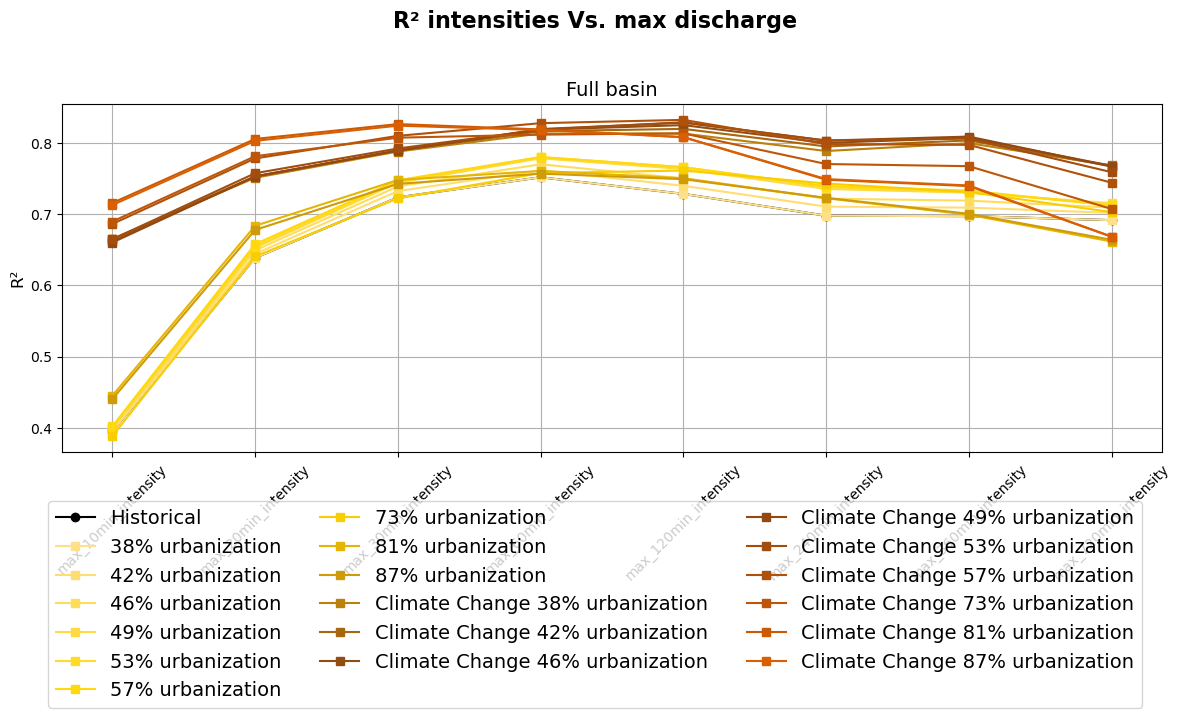

In [12]:
basin_rain_groups = ['full_basin']
# Initialize the figure for subplots
fig, axes = plt.subplots(1, len(basin_rain_groups), figsize=(12, 6), sharey=True)

# Ensure `axes` is always iterable
if len(basin_rain_groups) == 1:
    axes = [axes]

# Define multi-color gradients for Climate Change and Urbanization
climate_change_cmap = mcolors.LinearSegmentedColormap.from_list(
    "climate_change_gradient", 
    ["#2C7BB6", "#ABD9E9", "#E0F3F8", "#D73027"]
)
urbanization_cmap = mcolors.LinearSegmentedColormap.from_list(
    "urbanization_gradient", 
    ["#FEE08B", "#FFD700", "#8B4513", "#D95F02"]
)

# Number of scenarios in each category
climate_change_scenarios = [c for c in rain_shift_classes if "urbanization" in c[1] and "Climate Chagne" in c[1]]
urbanization_scenarios = [c for c in rain_shift_classes if "urbanization" in c[1] and "Climate Chagne" not in c[1]]

# Generate evenly spaced colors across the gradient for each category
climate_change_colors = [climate_change_cmap(i / max(1, len(climate_change_scenarios) - 1)) for i in range(len(climate_change_scenarios))]
urbanization_colors = [urbanization_cmap(i / max(1, len(urbanization_scenarios) - 1)) for i in range(len(urbanization_scenarios))]

# Assign colors to the rain_shift_classes
colors_dict = {}
for idx, scenario in enumerate(rain_shift_classes):
    if "urbanization" in scenario[1] and "Climate Chagne" in scenario[1]:
        colors_dict[scenario] = climate_change_colors.pop(0)
    elif "urbanization" in scenario[1]:
        colors_dict[scenario] = urbanization_colors.pop(0)
    else:
        colors_dict[scenario] = 'black'  # Default color for non-matching cases

# The rest of the plotting code remains the same

# Iterate over each group to create its subplot
for i, group in enumerate(basin_rain_groups):
    ax = axes[i]

    # Iterate over rain_shift_classes to plot scenarios
    for idx, (pickle_file, label_name) in enumerate(rain_shift_classes):
        # Build paths
        pickle_file_path = os.path.join(sim_dir, pickle_file)

        # Check if the pickle file exists
        if not os.path.exists(pickle_file_path):
            print(f"Pickle file {pickle_file_path} does not exist. Skipping...")
            continue  # Skip to the next iteration if the file does not exist

        # Load the data
        final_results_df = pd.read_pickle(pickle_file_path)

        # Filter data based on shift threshold
        final_results_df = final_results_df[
            (final_results_df[('y', '', '')] <= shift_threshold) & 
            (final_results_df[('y', '', '')] >= -shift_threshold)
        ]
        final_results_df = final_results_df[~final_results_df[('event_num', '', '')].isin(event_nums_to_filter_out)]

        # Define intensity columns for the current group
        intensity_cols = [
            ('historical', group, 'max_10min_intensity'),
            ('historical', group, 'max_20min_intensity'),
            ('historical', group, 'max_30min_intensity'),
            ('historical', group, 'max_60min_intensity'),
            ('historical', group, 'max_120min_intensity'),
            ('historical', group, 'max_240min_intensity'),
            ('historical', group, 'max_360min_intensity'),
            ('historical', group, 'max_720min_intensity'),
        ]
        future_intensity_cols = [(col[0].replace('historical', 'future'), col[1], col[2]) for col in intensity_cols]

        # Compute R² values
        historical_r2 = compute_r2(final_results_df, intensity_cols, historical_max_discharge_col)
        future_r2 = compute_r2(final_results_df, future_intensity_cols, future_max_discharge_col)

        # Determine line style based on scenario
#         if save_dir_file == 'optimal_model':
#             line_style = '-'
#         else:
#             line_style = '--'
        
        # Plot the historical data (for each group)
        if idx == 0:  # Plot historical data only once per group
            ax.plot(
                [col[2] for col in intensity_cols], 
                list(historical_r2.values()), 
                color='black', marker='o', linestyle='-', label='Historical'
            )

        # Plot the future data for this scenario
        ax.plot(
            [col[2] for col in future_intensity_cols], 
            list(future_r2.values()), 
            color=colors_dict[(pickle_file, label_name)], 
            marker='s', linestyle='-', label=f'{label_name}'
        )

    # Set title and labels
    ax.set_title(f'{group.capitalize().replace("_", " ")}', fontsize=14)
    ax.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for clarity

    if i == 0:
        ax.set_ylabel('R²', fontsize=12)
    ax.grid(True)

# Add an overall title for the figure
fig.suptitle('R² intensities Vs. max discharge', fontsize=16, fontweight='bold')

# Create a single legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, -0.2))

# Adjust layout for a clean, uniform appearance
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to include legend inside file

# Save and show the plot
# save_dir = r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\combined_shifts'
# os.makedirs(save_dir, exist_ok=True)
# combined_plot_path = os.path.join(save_dir, 'max_discharge_intensities_r2_comparison_combined.png')
# plt.savefig(combined_plot_path, bbox_inches='tight')  # Ensure legend fits inside the saved file
plt.show()


In [13]:
def create_enhanced_plots(rain_shift_classes, sim_dir, shift_threshold, event_nums_to_filter_out, 
                         historical_max_discharge_col, future_max_discharge_col):
    
    # Set up the figure with subplots
    fig = plt.figure(figsize=(20, 15))
    gs = plt.GridSpec(2, 2, figure=fig)
    
    # 1. Main Enhanced Plot
    ax1 = fig.add_subplot(gs[0, :])
    
    # Define color gradients as in original code
    climate_change_cmap = mcolors.LinearSegmentedColormap.from_list(
        "climate_change_gradient", 
        ["#2C7BB6", "#ABD9E9", "#E0F3F8", "#D73027"]
    )
    urbanization_cmap = mcolors.LinearSegmentedColormap.from_list(
        "urbanization_gradient", 
        ["#FEE08B", "#FFD700", "#8B4513", "#D95F02"]
    )
    
    # Classify scenarios as in original code
    climate_change_scenarios = [c for c in rain_shift_classes if "urbanization" in c[1] and "Climate Chagne" in c[1]]
    urbanization_scenarios = [c for c in rain_shift_classes if "urbanization" in c[1] and "Climate Chagne" not in c[1]]
    
    # Generate colors
    climate_change_colors = [climate_change_cmap(i / max(1, len(climate_change_scenarios) - 1)) 
                           for i in range(len(climate_change_scenarios))]
    urbanization_colors = [urbanization_cmap(i / max(1, len(urbanization_scenarios) - 1)) 
                          for i in range(len(urbanization_scenarios))]
    
    # Create colors dictionary
    colors_dict = {}
    for idx, scenario in enumerate(rain_shift_classes):
        if "urbanization" in scenario[1] and "Climate Chagne" in scenario[1]:
            colors_dict[scenario] = climate_change_colors.pop(0)
        elif "urbanization" in scenario[1]:
            colors_dict[scenario] = urbanization_colors.pop(0)
        else:
            colors_dict[scenario] = 'black'
    
    # Store R² values for other plots
    all_historical_r2 = []
    all_climate_r2 = []
    all_urban_r2 = []
    
    # Plot scenarios
    for group in ['full_basin']:
        intensity_cols = [
            ('historical', group, 'max_10min_intensity'),
            ('historical', group, 'max_20min_intensity'),
            ('historical', group, 'max_30min_intensity'),
            ('historical', group, 'max_60min_intensity'),
            ('historical', group, 'max_120min_intensity'),
            ('historical', group, 'max_240min_intensity'),
            ('historical', group, 'max_360min_intensity'),
            ('historical', group, 'max_720min_intensity'),
        ]
        future_intensity_cols = [(col[0].replace('historical', 'future'), col[1], col[2]) 
                               for col in intensity_cols]
        
        x_labels = [col[2].replace('max_', '').replace('_intensity', '') for col in intensity_cols]
        
        # Plot scenarios
        historical_data = None
        for idx, (pickle_file, label_name) in enumerate(rain_shift_classes):
            pickle_file_path = os.path.join(sim_dir, pickle_file)
            
            if not os.path.exists(pickle_file_path):
                print(f"Pickle file {pickle_file_path} does not exist. Skipping...")
                continue
                
            final_results_df = pd.read_pickle(pickle_file_path)
            final_results_df = final_results_df[
                (final_results_df[('y', '', '')] <= shift_threshold) & 
                (final_results_df[('y', '', '')] >= -shift_threshold)
            ]
            final_results_df = final_results_df[
                ~final_results_df[('event_num', '', '')].isin(event_nums_to_filter_out)
            ]
            
            # Compute R² values
            historical_r2 = compute_r2(final_results_df, intensity_cols, historical_max_discharge_col)
            future_r2 = compute_r2(final_results_df, future_intensity_cols, future_max_discharge_col)
            
            if idx == 0:
                ax1.plot(x_labels, list(historical_r2.values()), 
                        color='black', linewidth=3, label='Historical',
                        marker='o', markersize=10)
                historical_data = list(historical_r2.values())
                all_historical_r2.extend(historical_data)
            
            # Plot with color from dictionary
            color = colors_dict[(pickle_file, label_name)]
            ax1.plot(x_labels, list(future_r2.values()), 
                    color=color, linewidth=2, linestyle='-',
                    marker='s', markersize=8,
                    label=f'{label_name}')
            
            # Store values for other plots
            if "Climate Chagne" in label_name:
                all_climate_r2.extend(list(future_r2.values()))
            else:
                all_urban_r2.extend(list(future_r2.values()))
    
    # Enhance main plot
    ax1.set_title('R² Values: Rainfall Intensity vs Maximum Discharge', 
                  fontsize=16, pad=20)
    ax1.set_xlabel('Duration', fontsize=14)
    ax1.set_ylabel('r²', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    
    # 2. Box Plot
    ax2 = fig.add_subplot(gs[1, 0])
    box_data = [all_historical_r2, all_climate_r2, all_urban_r2]
    box_colors = ['black', climate_change_cmap(0.5), urbanization_cmap(0.5)]
    sns.boxplot(data=box_data, ax=ax2, palette=box_colors)
    ax2.set_xticklabels(['Historical', 'Climate\nChange', 'Urban'])
    ax2.set_title('Distribution of R² Values by Scenario Type', fontsize=14)
    ax2.set_ylabel('R² Value', fontsize=12)
    
    # 3. Heatmap
    ax3 = fig.add_subplot(gs[1, 1])
    heatmap_data = pd.DataFrame(index=x_labels)
    heatmap_data['Historical'] = historical_data
    heatmap_data['Climate Change'] = np.mean(np.array(all_climate_r2).reshape(-1, 8), axis=0)
    heatmap_data['Urban'] = np.mean(np.array(all_urban_r2).reshape(-1, 8), axis=0)
    
    sns.heatmap(heatmap_data.T, annot=True, cmap='RdYlBu_r', 
                fmt='.3f', ax=ax3, center=0.5)
    ax3.set_title('Average R² Values by Duration and Scenario Type', fontsize=14)
    
    plt.tight_layout()
    
    # Save the plot
    save_dir = r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\r_2_peakdischarge_rainintens'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, 'enhanced_r2_analysis.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

c:\Users\raznu\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\raznu\Anaconda3\lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


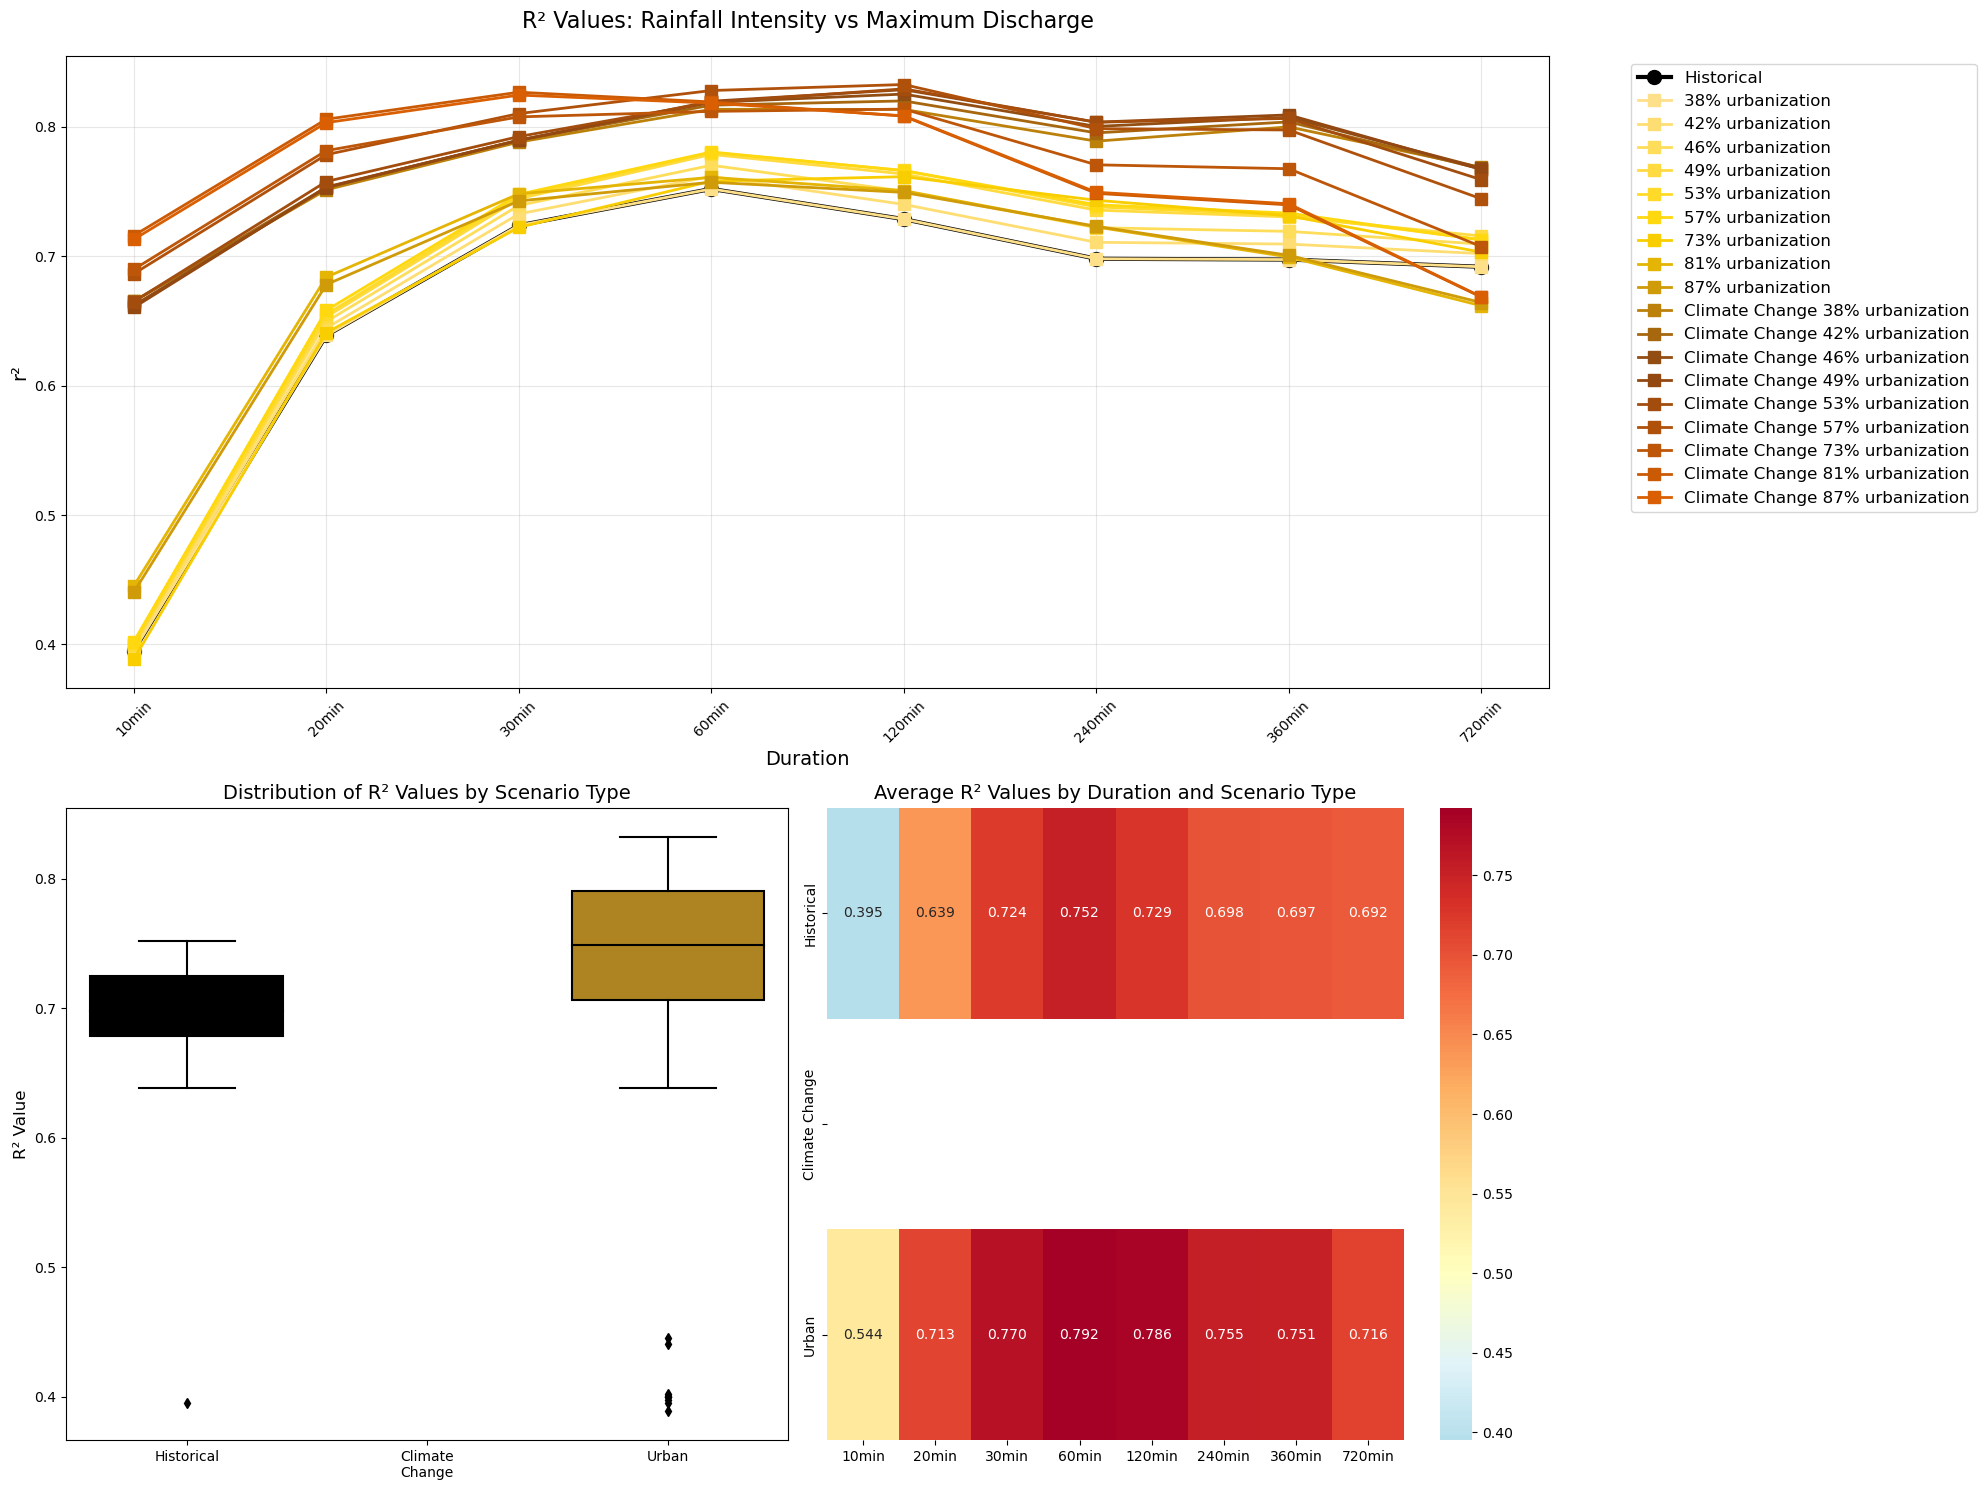

In [14]:
# Call the function with your existing variables:
create_enhanced_plots(
    rain_shift_classes=rain_shift_classes,
    sim_dir=sim_dir,
    shift_threshold=shift_threshold,
    event_nums_to_filter_out=event_nums_to_filter_out,
    historical_max_discharge_col=historical_max_discharge_col,
    future_max_discharge_col=future_max_discharge_col
)

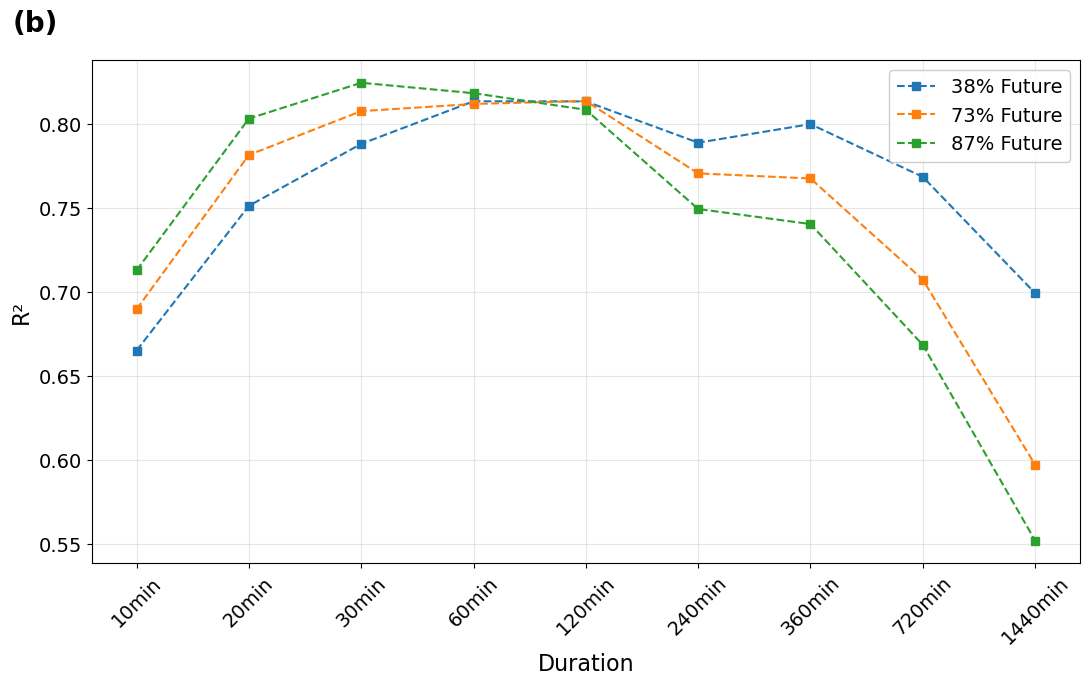

In [15]:
# =============================
# Plot R^2 vs rainfall intensity duration for selected impervious percentages
# with figure label "a", no title, larger fonts, and legend inside the axes
# =============================

# Assumes these are already defined in the notebook:
# os, pd, np, plt, LinearRegression, r2_score
# sim_dir, rain_shift_classes, shift_threshold, event_nums_to_filter_out

# Select the impervious percentages to plot (edit this list)
selected_percentages = [38, 73, 87]

# Group and duration labels
_group = 'full_basin'
_duration_labels = ['10min', '20min', '30min', '60min', '120min', '240min', '360min', '720min', '1440min']
_intensity_cols_fut = [('future', _group, f'max_{d}_intensity') for d in _duration_labels]

# Local R^2 helper to avoid ambiguity with any other compute_r2 defined in the notebook
def _compute_r2_lr(df, intensity_cols, discharge_col):
    values = []
    for col in intensity_cols:
        valid = df[[col, discharge_col]].dropna()
        if valid.empty:
            values.append(np.nan)
            continue
        X = valid[col].values.reshape(-1, 1)
        y = valid[discharge_col].values
        model = LinearRegression().fit(X, y)
        y_pred = model.predict(X)
        values.append(r2_score(y, y_pred))
    return values

# Color mapping per selected percentage
_colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(selected_percentages))))
_percent_color = {p: _colors[i % len(_colors)] for i, p in enumerate(selected_percentages)}

# Figure and axes
fig, ax = plt.subplots(figsize=(11, 7))

for p in selected_percentages:
    # Find the matching scenario for this percentage (Future Climate Change only)
    fut_entry = next(((f, l) for f, l in rain_shift_classes if l == f'Climate Change {p}% urbanization'), None)

    if fut_entry is None:
        print(f'No scenarios found for {p}%. Skipping.')
        continue

    _file, _label = fut_entry
    _path = os.path.join(sim_dir, _file)
    if os.path.exists(_path):
        _df = pd.read_pickle(_path)
        _df = _df[(_df[('y', '', '')] <= shift_threshold) & (_df[('y', '', '')] >= -shift_threshold)]
        _df = _df[~_df[('event_num', '', '')].isin(event_nums_to_filter_out)]
        _fut_r2 = _compute_r2_lr(_df, _intensity_cols_fut, ('future', 'basin discharge', 'max_discharge'))
        ax.plot(_duration_labels, _fut_r2,
                color=_percent_color[p], marker='s', linestyle='--',
                label=f'{p}% Future')
    else:
        print(f'Missing pickle for future {p}%: {_path}')

# Axes labels (larger fonts)
ax.set_xlabel('Duration', fontsize=16)
ax.set_ylabel('R²', fontsize=16)

# Ticks (larger fonts)
ax.tick_params(axis='both', labelsize=14)
ax.tick_params(axis='x', rotation=45)

# Grid
ax.grid(True, alpha=0.3)

# Legend inside the axes (larger font)
ax.legend(loc='upper right', fontsize=14, frameon=True, framealpha=0.95)

# Figure label "(a)" at the top left inside the axes
ax.text(-0.08, 1.1, '(b)', transform=ax.transAxes,
        fontsize=20, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()


In [16]:
def compute_r2(df, intensity_cols, discharge_col):
    """Compute R² values for given intensity columns and discharge column."""
    r2_values = []
    for col in intensity_cols:
        x = df[col].values
        y = df[discharge_col].values
        if len(x) > 0 and len(y) > 0:
            correlation_matrix = np.corrcoef(x, y)
            correlation_xy = correlation_matrix[0, 1]
            r2_values.append(correlation_xy**2)
        else:
            r2_values.append(np.nan)
    return r2_values


In [17]:
def create_enhanced_plots(rain_shift_classes, sim_dir, shift_threshold, event_nums_to_filter_out, 
                          historical_max_discharge_col, future_max_discharge_col):
    # Set up the figure
    plt.figure(figsize=(15, 10))

    # Define intervals and durations for X-axis
    intervals = ['10min', '20min', '30min', '60min', '120min', '240min', '360min', '720min', '1440min']
    durations = [10, 20, 30, 60, 120, 240, 360, 720, 1440]

    # Prepare storage for min, max, and mean values for each interval and scenario type
    future_min = {interval: [] for interval in intervals}
    future_max = {interval: [] for interval in intervals}
    future_mean = {interval: [] for interval in intervals}
    historical_min = {interval: [] for interval in intervals}
    historical_max = {interval: [] for interval in intervals}
    historical_mean = {interval: [] for interval in intervals}

    # Process each scenario
    for pickle_file, label_name in rain_shift_classes:
        pickle_file_path = os.path.join(sim_dir, pickle_file)
        
        if not os.path.exists(pickle_file_path):
            print(f"Pickle file {pickle_file_path} does not exist. Skipping...")
            continue

        # Load data and filter
        final_results_df = pd.read_pickle(pickle_file_path)
        final_results_df = final_results_df[
            (final_results_df[('y', '', '')] <= shift_threshold) & 
            (final_results_df[('y', '', '')] >= -shift_threshold)
        ]
        final_results_df = final_results_df[
            ~final_results_df[('event_num', '', '')].isin(event_nums_to_filter_out)
        ]

        # Define intensity columns
        intensity_cols = [
            ('future', 'full_basin', f'max_{interval}_intensity') for interval in intervals
        ]

        # Compute R² for future scenarios
        future_r2 = compute_r2(final_results_df, intensity_cols, future_max_discharge_col)

        # Determine scenario type (Future climate or Historical climate)
        is_future_climate = "climate change" in label_name.lower()

        # Store min, max, and mean values for each interval
        for i, interval in enumerate(intervals):
            if is_future_climate:
                future_min[interval].append(future_r2[i])
                future_max[interval].append(future_r2[i])
                future_mean[interval].append(future_r2[i])
            else:
                historical_min[interval].append(future_r2[i])
                historical_max[interval].append(future_r2[i])
                historical_mean[interval].append(future_r2[i])

    # Compute overall min, max, and mean values for plotting
    future_min = {k: np.min(v) if v else np.nan for k, v in future_min.items()}
    future_max = {k: np.max(v) if v else np.nan for k, v in future_max.items()}
    future_mean = {k: np.mean(v) if v else np.nan for k, v in future_mean.items()}
    historical_min = {k: np.min(v) if v else np.nan for k, v in historical_min.items()}
    historical_max = {k: np.max(v) if v else np.nan for k, v in historical_max.items()}
    historical_mean = {k: np.mean(v) if v else np.nan for k, v in historical_mean.items()}

    # Plot shaded areas and mean lines for each scenario type
    plt.fill_between(durations, [future_min[k] for k in intervals], [future_max[k] for k in intervals], 
                     color='orange', alpha=0.5, label='Future climate')
    plt.plot(durations, [future_mean[k] for k in intervals], color='darkorange', linestyle='-', 
             linewidth=2, label='Future climate mean')

    plt.fill_between(durations, [historical_min[k] for k in intervals], [historical_max[k] for k in intervals], 
                     color='blue', alpha=0.5, label='Historical climate')
    plt.plot(durations, [historical_mean[k] for k in intervals], color='darkblue', linestyle='-', 
             linewidth=2, label='Historical climate mean')

    # Customize plot
    plt.xlabel('Duration (min)', fontsize=20)
    plt.ylabel('r²\n peak discharge vs. max rain intensity', fontsize=20)
    plt.xscale('log')  # Set X-axis to logarithmic scale
    plt.xticks(durations, [str(d) for d in durations], fontsize=20)

    plt.yticks(fontsize=20)
    plt.xlim([durations[0], durations[-1]])  # Set X-axis limits to the first and last intervals
    plt.legend(fontsize=20, loc='lower right')
    plt.grid(alpha=0.3, which='both', linestyle='--')  # Show grid for both major and minor ticks

    # Save the plot
    save_dir = r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\r_2_peakdischarge_rainintens'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, 'enhanced_r2_range_analysis_with_means.png'), dpi=300, bbox_inches='tight')
    plt.show()


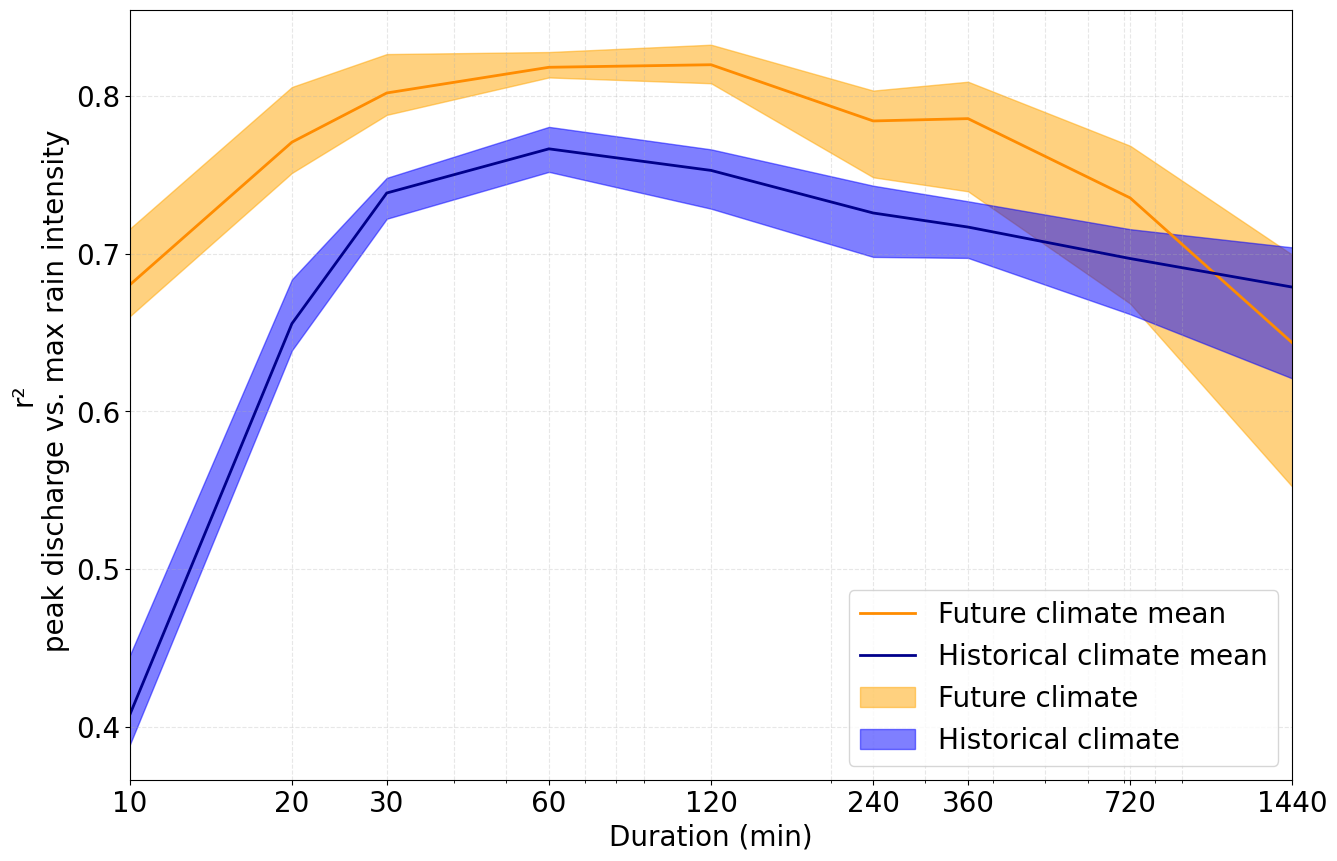

In [18]:
create_enhanced_plots(rain_shift_classes, sim_dir, shift_threshold, event_nums_to_filter_out, historical_max_discharge_col, future_max_discharge_col)


Figure saved to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_5.pdf


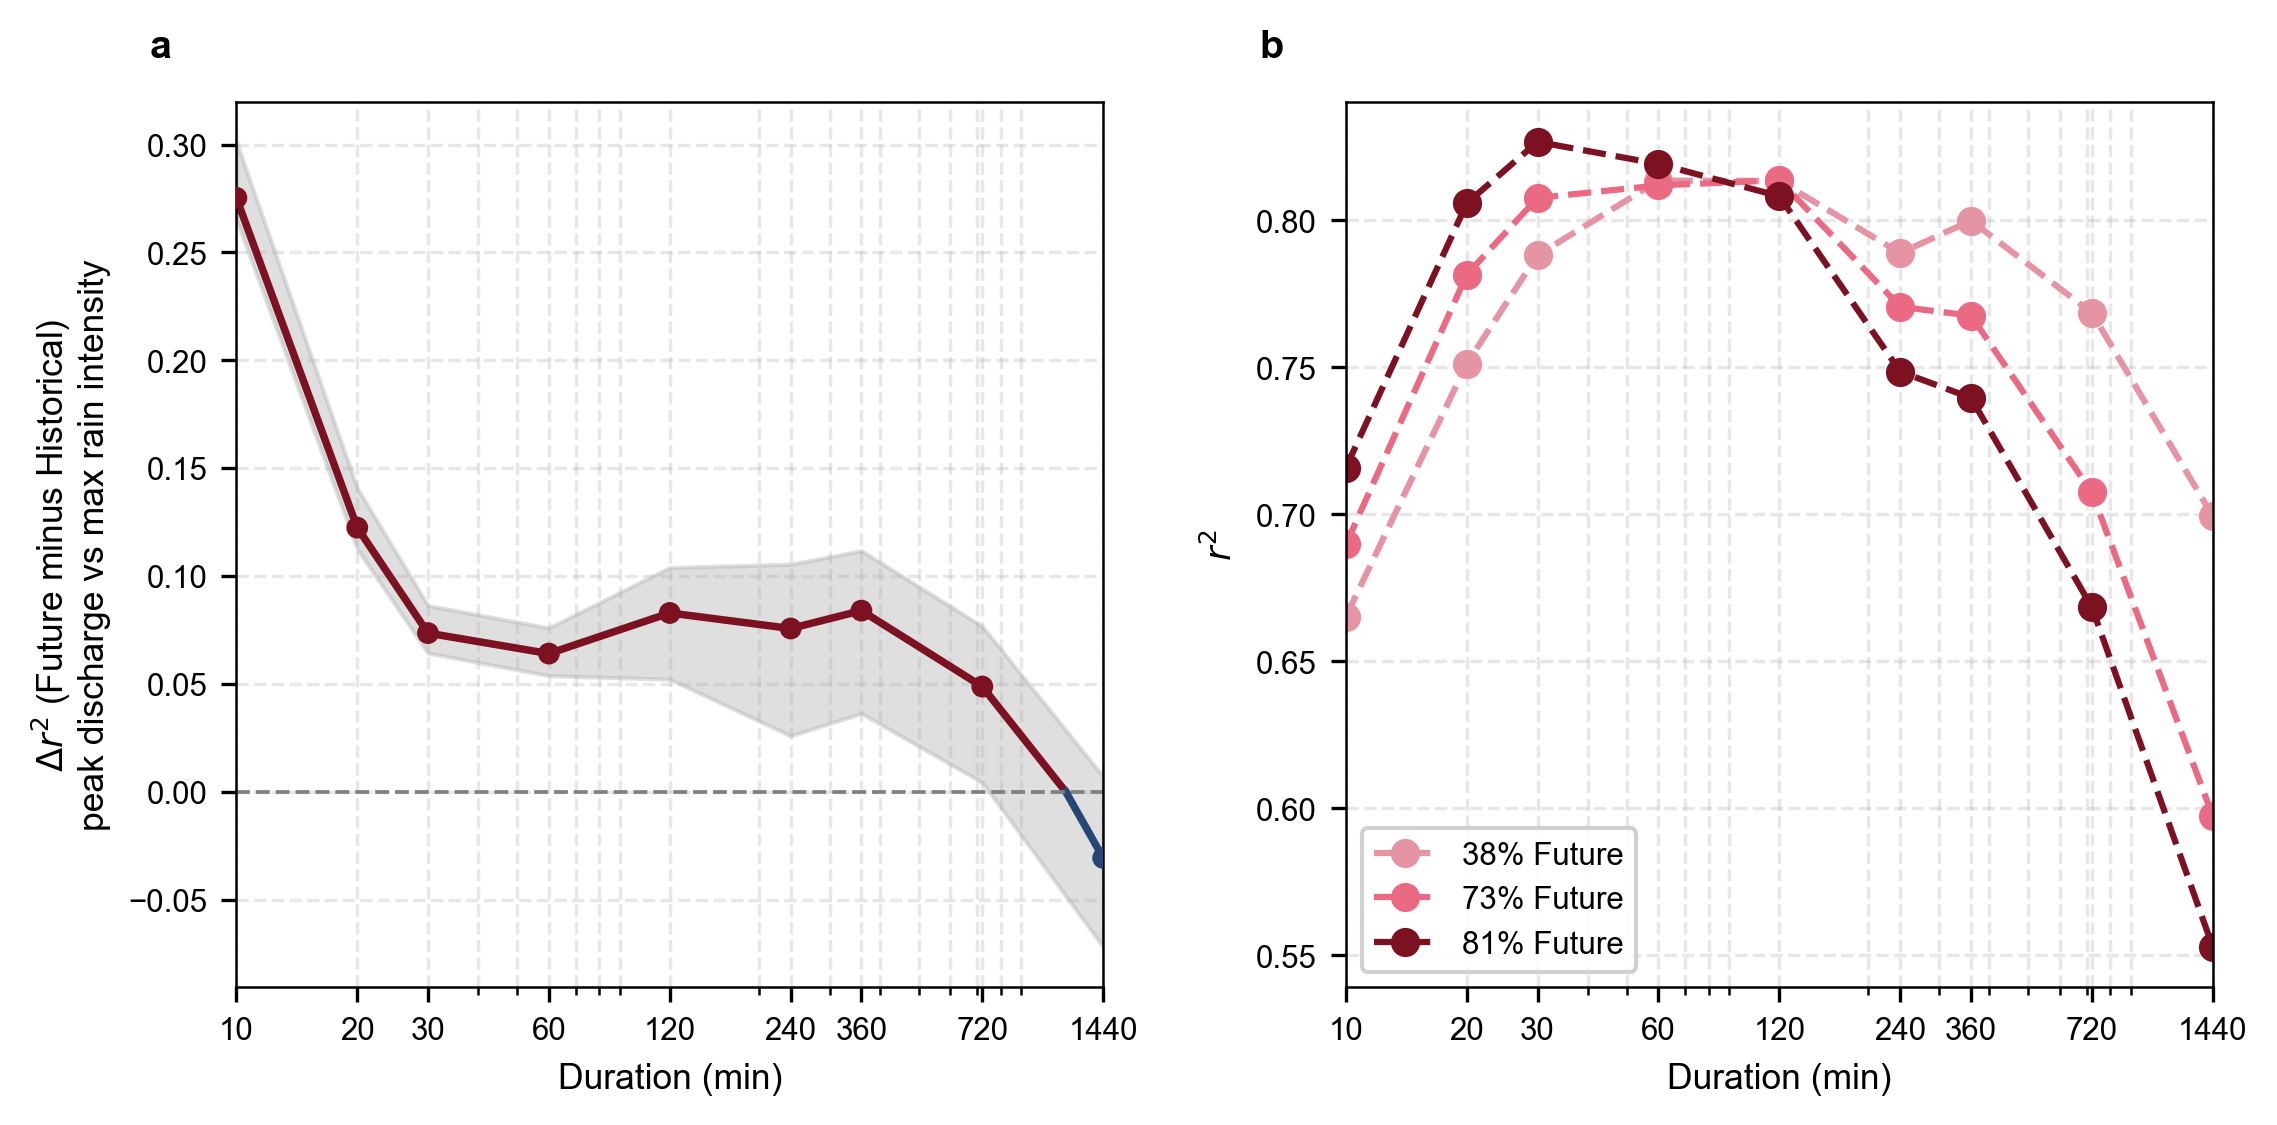

(<Figure size 2160x1080 with 2 Axes>,
 (<AxesSubplot:xlabel='Duration (min)', ylabel='$\\Delta r^2$ (Future minus Historical)\npeak discharge vs max rain intensity'>,
  <AxesSubplot:xlabel='Duration (min)', ylabel='$r^2$'>))

In [21]:
# ============================================
#  Figure 5: ΔR² vs duration and future R² vs duration
#  Nature-ready two-panel figure with PDF saving
# ============================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# ----------------------------
# Figure configuration (Nature-like)
# ----------------------------
FIG_W_IN = 7.2   # ~183 mm
FIG_H_IN = 3.6   # compact 1x2 layout

FS_LABEL = 8.5
FS_TICK  = 7.5
FS_LEG   = 7.5
FS_TAG   = 9.5

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Default save directory
FIG_DIR = Path(
    r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
)

# Durations
intervals  = ['10min', '20min', '30min', '60min', '120min', '240min', '360min', '720min', '1440min']
durations  = [10, 20, 30, 60, 120, 240, 360, 720, 1440]  # minutes
_group     = 'full_basin'


# ----------------------------
# HELPERS
# ----------------------------
def _r2_linear(df, intensity_cols, discharge_col):
    """Compute R² via linear regression for each intensity column vs a discharge column."""
    vals = []
    for col in intensity_cols:
        valid = df[[col, discharge_col]].dropna()
        if valid.empty:
            vals.append(np.nan)
            continue
        X = valid[col].values.reshape(-1, 1)
        y = valid[discharge_col].values
        mdl = LinearRegression().fit(X, y)
        yp  = mdl.predict(X)
        vals.append(r2_score(y, yp))
    return np.array(vals, dtype=float)


def _load_and_filter(path):
    """Load pickle and apply common filters."""
    df = pd.read_pickle(path)
    df = df[(df[('y', '', '')] <= shift_threshold) & (df[('y', '', '')] >= -shift_threshold)]
    df = df[~df[('event_num', '', '')].isin(event_nums_to_filter_out)]
    return df


# ============================================================
#                FULL FIGURE 5 FUNCTION
# ============================================================
def make_figure_5(
    filename: str = "Fig_5",
    save_dir: Path = FIG_DIR,
    file_format: str = "pdf",
    show: bool = True,
):
    """
    Build Figure 5 and optionally save as PDF.

    Parameters
    ----------
    filename : str
        File name without extension.
    save_dir : Path
        Output directory for the figure.
    show : bool
        Show figure on screen.
    """

    # ----------------------------
    # Panel (a): ΔR² aggregated across matched percentages
    # ----------------------------
    hist_map, fut_map = {}, {}

    for pf, lbl in rain_shift_classes:
        low = lbl.lower()
        m = re.search(r'(\d+)%\s*urbanization', low)
        if not m:
            continue
        pct = int(m.group(1))

        # Future climate-change runs
        if "climate change" in low:
            fut_map[pct] = (pf, lbl)

        # Historical urbanization runs
        elif "urbanization" in low and "climate" not in low:
            hist_map[pct] = (pf, lbl)

    paired_pcts = sorted(set(hist_map).intersection(fut_map))

    diffs_by_interval = {iv: [] for iv in intervals}

    if paired_pcts:
        hist_cols = [('historical', _group, f'max_{iv}_intensity') for iv in intervals]
        fut_cols  = [('future',    _group, f'max_{iv}_intensity') for iv in intervals]

        for pct in paired_pcts:
            h_path = os.path.join(sim_dir, hist_map[pct][0])
            f_path = os.path.join(sim_dir, fut_map[pct][0])

            if not (os.path.exists(h_path) and os.path.exists(f_path)):
                continue

            h_df = _load_and_filter(h_path)
            f_df = _load_and_filter(f_path)

            h_r2 = _r2_linear(h_df, hist_cols, ('historical', 'basin discharge', 'max_discharge'))
            f_r2 = _r2_linear(f_df, fut_cols,  ('future',    'basin discharge', 'max_discharge'))

            d_r2 = f_r2 - h_r2
            for i, iv in enumerate(intervals):
                diffs_by_interval[iv].append(d_r2[i])

    diff_min  = [np.nanmin(diffs_by_interval[iv]) if diffs_by_interval[iv] else np.nan for iv in intervals]
    diff_max  = [np.nanmax(diffs_by_interval[iv]) if diffs_by_interval[iv] else np.nan for iv in intervals]
    diff_mean = [np.nanmean(diffs_by_interval[iv]) if diffs_by_interval[iv] else np.nan for iv in intervals]

    diff_mean_arr = np.array(diff_mean, dtype=float)
    dur_arr       = np.array(durations, dtype=float)

    # ----------------------------
    # Panel (b): R² vs duration for selected percentages
    # ----------------------------
    selected_percentages = [38, 73, 81]

    _intensity_cols_fut  = [('future', _group, f'max_{d}_intensity') for d in intervals]

    future_palette = [
        "#E594A4",
        "#E96A82",
        "#7B1121",
    ]
    _percent_color = {p: future_palette[i] for i, p in enumerate(selected_percentages)}

    # ----------------------------
    # Colors for panel (a)
    # ----------------------------
    shade_color   = "#b0b0b0"
    historic_col  = "#264775"   # dark blue
    future_col    = "#7B1121"   # dark red

    # ----------------------------
    # CREATE FIGURE
    # ----------------------------
    fig, (ax_a, ax_b) = plt.subplots(
        1, 2,
        figsize=(FIG_W_IN, FIG_H_IN),
        dpi=300
    )
    fig.subplots_adjust(
        left=0.08,
        right=0.995,
        top=0.98,
        bottom=0.16,
        wspace=0.28
    )

    # ============================================================
    #                     PANEL (a)
    # ============================================================
    # Shaded range (neutral grey)
    ax_a.fill_between(
        dur_arr,
        diff_min,
        diff_max,
        color=shade_color,
        alpha=0.4
    )

    # Draw mean line in colored segments, changing color when crossing 0
    for i in range(len(dur_arr) - 1):
        x1, x2 = dur_arr[i], dur_arr[i + 1]
        y1, y2 = diff_mean_arr[i], diff_mean_arr[i + 1]

        if np.isnan(y1) or np.isnan(y2):
            continue

        # Both on same side of zero
        if (y1 >= 0 and y2 >= 0) or (y1 <= 0 and y2 <= 0):
            color = future_col if y1 >= 0 else historic_col
            ax_a.plot([x1, x2], [y1, y2], color=color, linewidth=1.8)
        else:
            # Segment crosses zero, split into two colored parts
            x0 = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            if y1 > 0:
                # future above, historic below
                ax_a.plot([x1, x0], [y1, 0], color=future_col, linewidth=1.8)
                ax_a.plot([x0, x2], [0, y2], color=historic_col, linewidth=1.8)
            else:
                ax_a.plot([x1, x0], [y1, 0], color=historic_col, linewidth=1.8)
                ax_a.plot([x0, x2], [0, y2], color=future_col, linewidth=1.8)

    # Markers colored by sign
    marker_colors = [future_col if y >= 0 else historic_col for y in diff_mean_arr]
    ax_a.scatter(dur_arr, diff_mean_arr, color=marker_colors, s=18, zorder=3)

    ax_a.axhline(0.0, linestyle='--', linewidth=0.9, color='gray')

    ax_a.set_xscale('log')
    ax_a.set_xlim(durations[0], durations[-1])
    ax_a.set_xticks(durations)
    ax_a.set_xticklabels([str(d) for d in durations], fontsize=FS_TICK)
    ax_a.tick_params(axis='y', labelsize=FS_TICK)
    ax_a.grid(alpha=0.3, which='both', linestyle='--')

    ax_a.set_xlabel('Duration (min)', fontsize=FS_LABEL)
    ax_a.set_ylabel(
        r'$\Delta r^2$ (Future minus Historical)' + '\n'
        'peak discharge vs max rain intensity',
        fontsize=FS_LABEL
    )
    ax_a.text(-0.1, 1.05, 'a', transform=ax_a.transAxes,
              fontsize=FS_TAG, fontweight='bold')

#     legend_handles = [
#         Line2D([0], [0], color=historic_col, marker='o', linestyle='-',
#                label=r'Mean $\Delta R^2$ (historic $>$ future)'),
#         Line2D([0], [0], color=future_col, marker='o', linestyle='-',
#                label=r'Mean $\Delta R^2$ (future $>$ historic)'),
#         Patch(facecolor=shade_color, edgecolor='none', alpha=0.4,
#               label=r'$\Delta R^2$ range'),
#     ]
#     ax_a.legend(handles=legend_handles, fontsize=FS_LEG,
#                 loc='lower left', frameon=True, framealpha=0.9)

    # ============================================================
    #                     PANEL (b)
    # ============================================================
    for p in selected_percentages:
        fut_entry = next(
            ((f, l) for f, l in rain_shift_classes if l == f'Climate Change {p}% urbanization'),
            None
        )
        if fut_entry is None:
            continue

        _file, _ = fut_entry
        _path = os.path.join(sim_dir, _file)
        if not os.path.exists(_path):
            continue

        _df = _load_and_filter(_path)
        _fut_r2 = _r2_linear(
            _df,
            _intensity_cols_fut,
            ('future', 'basin discharge', 'max_discharge')
        )

        ax_b.plot(
            durations,
            _fut_r2,
            color=_percent_color[p],
            marker='o',
            linestyle='--',
            label=f'{p}% Future'
        )

    ax_b.set_xscale('log')
    ax_b.set_xlim(durations[0], durations[-1])
    ax_b.set_xticks(durations)
    ax_b.set_xticklabels([str(d) for d in durations], fontsize=FS_TICK)
    ax_b.tick_params(axis='y', labelsize=FS_TICK)
    ax_b.grid(alpha=0.3, which='both', linestyle='--')

    ax_b.set_xlabel('Duration (min)', fontsize=FS_LABEL)
    ax_b.set_ylabel(r'$r^2$', fontsize=FS_LABEL)

    ax_b.text(-0.1, 1.05, 'b', transform=ax_b.transAxes,
              fontsize=FS_TAG, fontweight='bold')

    ax_b.legend(loc='lower left', fontsize=FS_LEG, frameon=True, framealpha=0.9)

    # ============================================================
    #                      SAVE FIGURE
    # ============================================================
    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"{filename}.{file_format}"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Figure saved to: {out_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, (ax_a, ax_b)


# ============================================================
# HOW TO RUN
# ============================================================
make_figure_5(filename="Fig_5")  # default name
# make_figure_5(filename="Fig_5_r2")  # custom name


Figure saved to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_5_Spaghetti.pdf


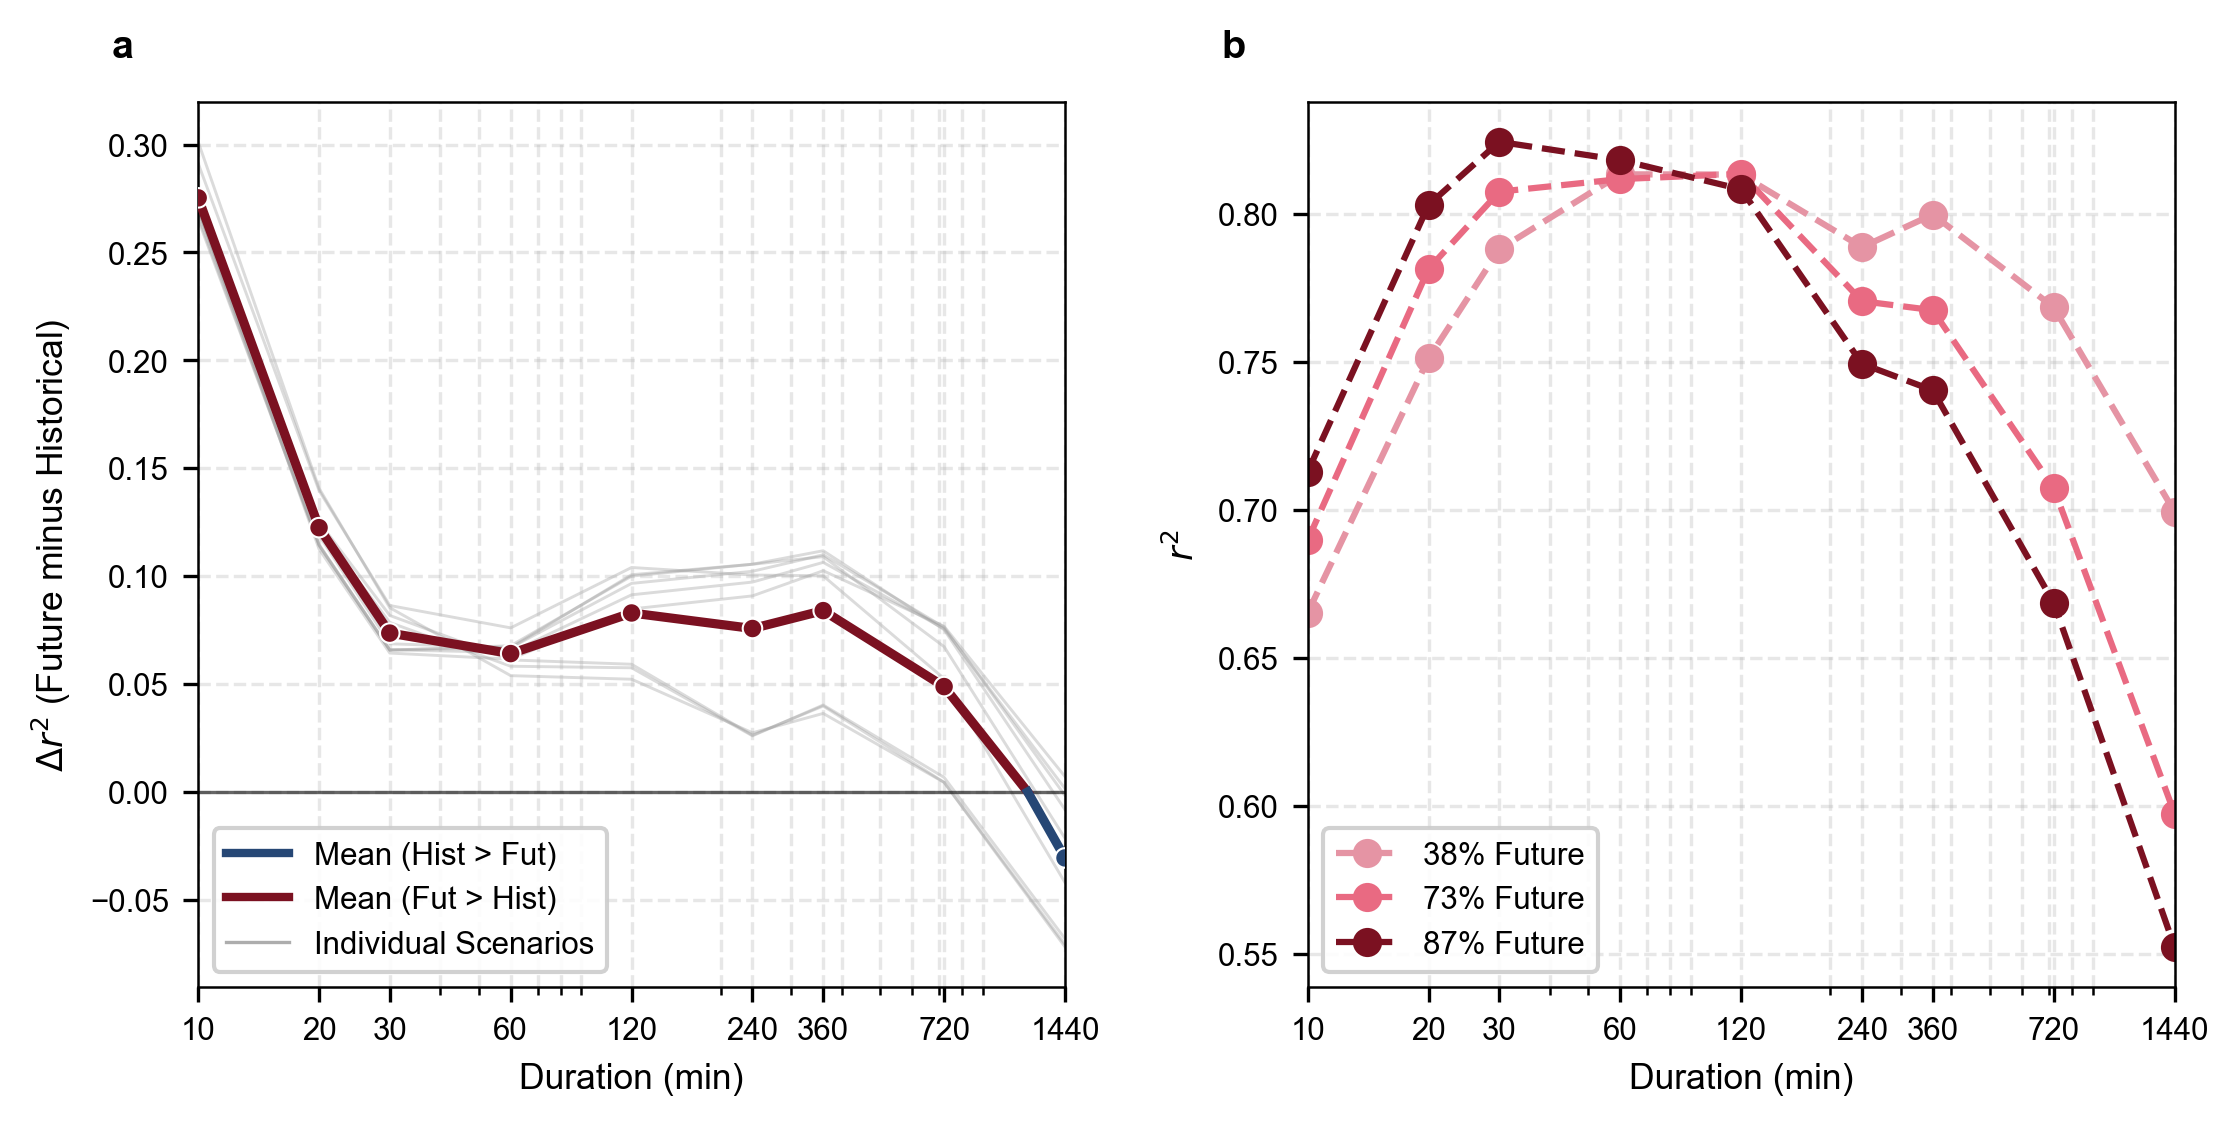

In [20]:
# ============================================
#  Figure 5 ALTERNATIVE: With Individual Traces
#  Shows "Spaghetti" lines instead of just shade
# ============================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ----------------------------
# Figure configuration
# ----------------------------
FIG_W_IN = 7.2
FIG_H_IN = 3.6

FS_LABEL = 8.5
FS_TICK  = 7.5
FS_LEG   = 7.5
FS_TAG   = 9.5

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Save directory
FIG_DIR = Path(r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures")

# Configs
intervals  = ['10min', '20min', '30min', '60min', '120min', '240min', '360min', '720min', '1440min']
durations  = [10, 20, 30, 60, 120, 240, 360, 720, 1440]
_group     = 'full_basin'

# ----------------------------
# HELPERS (Same as before)
# ----------------------------
def _r2_linear(df, intensity_cols, discharge_col):
    vals = []
    for col in intensity_cols:
        valid = df[[col, discharge_col]].dropna()
        if valid.empty:
            vals.append(np.nan)
            continue
        X = valid[col].values.reshape(-1, 1)
        y = valid[discharge_col].values
        mdl = LinearRegression().fit(X, y)
        yp  = mdl.predict(X)
        vals.append(r2_score(y, yp))
    return np.array(vals, dtype=float)

def _load_and_filter(path):
    # Ensure these variables (shift_threshold, event_nums_to_filter_out)
    # exist in your global namespace or passed as args. 
    # Assuming they exist from your previous cells.
    df = pd.read_pickle(path)
    if 'shift_threshold' in globals():
        df = df[(df[('y', '', '')] <= shift_threshold) & (df[('y', '', '')] >= -shift_threshold)]
    if 'event_nums_to_filter_out' in globals():
        df = df[~df[('event_num', '', '')].isin(event_nums_to_filter_out)]
    return df

# ============================================================
#          FIGURE 5 FUNCTION - SPAGHETTI VERSION
# ============================================================
def make_figure_5_traces(
    filename: str = "Fig_5_Spaghetti",
    save_dir: Path = FIG_DIR,
    file_format: str = "pdf",
    show: bool = True,
):
    
    # -------------------------------------------------------
    # 1. Data Processing for Panel (a)
    # -------------------------------------------------------
    hist_map, fut_map = {}, {}

    # Iterate over global 'rain_shift_classes'
    for pf, lbl in rain_shift_classes:
        low = lbl.lower()
        m = re.search(r'(\d+)%\s*urbanization', low)
        if not m: continue
        pct = int(m.group(1))

        if "climate change" in low:
            fut_map[pct] = (pf, lbl)
        elif "urbanization" in low and "climate" not in low:
            hist_map[pct] = (pf, lbl)

    paired_pcts = sorted(set(hist_map).intersection(fut_map))

    # We will store the traces here: {pct: numpy_array_of_diffs}
    scenario_traces = {}
    diffs_by_interval = {iv: [] for iv in intervals}

    if paired_pcts:
        hist_cols = [('historical', _group, f'max_{iv}_intensity') for iv in intervals]
        fut_cols  = [('future',    _group, f'max_{iv}_intensity') for iv in intervals]

        for pct in paired_pcts:
            h_path = os.path.join(sim_dir, hist_map[pct][0])
            f_path = os.path.join(sim_dir, fut_map[pct][0])

            if not (os.path.exists(h_path) and os.path.exists(f_path)):
                continue

            h_df = _load_and_filter(h_path)
            f_df = _load_and_filter(f_path)

            h_r2 = _r2_linear(h_df, hist_cols, ('historical', 'basin discharge', 'max_discharge'))
            f_r2 = _r2_linear(f_df, fut_cols,  ('future',    'basin discharge', 'max_discharge'))

            d_r2 = f_r2 - h_r2
            
            # Store the individual trace
            scenario_traces[pct] = d_r2

            # Collect for mean calculation
            for i, iv in enumerate(intervals):
                diffs_by_interval[iv].append(d_r2[i])

    # Calculate Mean stats
    diff_mean = [np.nanmean(diffs_by_interval[iv]) if diffs_by_interval[iv] else np.nan for iv in intervals]
    diff_mean_arr = np.array(diff_mean, dtype=float)
    dur_arr       = np.array(durations, dtype=float)

    # ----------------------------
    # Colors
    # ----------------------------
    historic_col  = "#264775"   # dark blue
    future_col    = "#7B1121"   # dark red
    
    # ----------------------------
    # Create Figure
    # ----------------------------
    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(FIG_W_IN, FIG_H_IN), dpi=300)
    fig.subplots_adjust(left=0.08, right=0.995, top=0.98, bottom=0.16, wspace=0.28)

    # ============================================================
    # PANEL (a): Spaghetti + Mean
    # ============================================================
    
    # 1. Plot INDIVIDUAL TRACES (The thin lines)
    # We use a neutral gray so the mean stands out
    for pct, trace in scenario_traces.items():
        ax_a.plot(
            dur_arr, 
            trace, 
            color='#999999',  # Neutral gray
            alpha=0.35,       # Transparency is key for spaghetti plots
            linewidth=0.7,    # Thin line
            zorder=1          # Behind the mean line
        )

    # 2. Plot MEAN LINE (with color switch logic)
    for i in range(len(dur_arr) - 1):
        x1, x2 = dur_arr[i], dur_arr[i + 1]
        y1, y2 = diff_mean_arr[i], diff_mean_arr[i + 1]

        if np.isnan(y1) or np.isnan(y2): continue

        if (y1 >= 0 and y2 >= 0) or (y1 <= 0 and y2 <= 0):
            color = future_col if y1 >= 0 else historic_col
            ax_a.plot([x1, x2], [y1, y2], color=color, linewidth=2.2, zorder=5)
        else:
            # Crossing zero
            x0 = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            if y1 > 0:
                ax_a.plot([x1, x0], [y1, 0], color=future_col, linewidth=2.2, zorder=5)
                ax_a.plot([x0, x2], [0, y2], color=historic_col, linewidth=2.2, zorder=5)
            else:
                ax_a.plot([x1, x0], [y1, 0], color=historic_col, linewidth=2.2, zorder=5)
                ax_a.plot([x0, x2], [0, y2], color=future_col, linewidth=2.2, zorder=5)

    # Markers for mean
    marker_colors = [future_col if y >= 0 else historic_col for y in diff_mean_arr]
    ax_a.scatter(dur_arr, diff_mean_arr, color=marker_colors, s=22, zorder=6, edgecolor='white', linewidth=0.5)

    # Reference line
    ax_a.axhline(0.0, linestyle='-', linewidth=0.8, color='black', alpha=0.6)

    # Formatting Panel A
    ax_a.set_xscale('log')
    ax_a.set_xlim(durations[0], durations[-1])
    ax_a.set_xticks(durations)
    ax_a.set_xticklabels([str(d) for d in durations], fontsize=FS_TICK)
    ax_a.tick_params(axis='y', labelsize=FS_TICK)
    ax_a.grid(alpha=0.3, which='both', linestyle='--')

    ax_a.set_xlabel('Duration (min)', fontsize=FS_LABEL)
    ax_a.set_ylabel(r'$\Delta r^2$ (Future minus Historical)', fontsize=FS_LABEL)
    ax_a.text(-0.1, 1.05, 'a', transform=ax_a.transAxes, fontsize=FS_TAG, fontweight='bold')

    # Add legend explaining the lines
    custom_lines = [
        Line2D([0], [0], color=historic_col, lw=2, label='Mean (Hist > Fut)'),
        Line2D([0], [0], color=future_col, lw=2, label='Mean (Fut > Hist)'),
        Line2D([0], [0], color='#999999', lw=0.8, alpha=0.8, label='Individual Scenarios')
    ]
    ax_a.legend(handles=custom_lines, fontsize=FS_LEG, loc='lower left', frameon=True, framealpha=0.9)


    # ============================================================
    # PANEL (b): Unchanged (Representative curves)
    # ============================================================
    selected_percentages = [38, 73, 87]
    _intensity_cols_fut  = [('future', _group, f'max_{d}_intensity') for d in intervals]
    future_palette = ["#E594A4", "#E96A82", "#7B1121"]
    _percent_color = {p: future_palette[i] for i, p in enumerate(selected_percentages)}

    for p in selected_percentages:
        fut_entry = next(((f, l) for f, l in rain_shift_classes if l == f'Climate Change {p}% urbanization'), None)
        if fut_entry is None: continue

        _file, _ = fut_entry
        _path = os.path.join(sim_dir, _file)
        if not os.path.exists(_path): continue

        _df = _load_and_filter(_path)
        _fut_r2 = _r2_linear(_df, _intensity_cols_fut, ('future', 'basin discharge', 'max_discharge'))

        ax_b.plot(durations, _fut_r2, color=_percent_color[p], marker='o', linestyle='--', label=f'{p}% Future')

    ax_b.set_xscale('log')
    ax_b.set_xlim(durations[0], durations[-1])
    ax_b.set_xticks(durations)
    ax_b.set_xticklabels([str(d) for d in durations], fontsize=FS_TICK)
    ax_b.tick_params(axis='y', labelsize=FS_TICK)
    ax_b.grid(alpha=0.3, which='both', linestyle='--')
    ax_b.set_xlabel('Duration (min)', fontsize=FS_LABEL)
    ax_b.set_ylabel(r'$r^2$', fontsize=FS_LABEL)
    ax_b.text(-0.1, 1.05, 'b', transform=ax_b.transAxes, fontsize=FS_TAG, fontweight='bold')
    ax_b.legend(loc='lower left', fontsize=FS_LEG, frameon=True, framealpha=0.9)

    # Save
    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"{filename}.{file_format}"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Figure saved to: {out_path}")
    
    if show:
        plt.show()

# Run it
make_figure_5_traces()